# Time-TRUST Low-RUL Stability Results

Notebook para consolidar y visualizar los resultados del sweep low-RUL de Time-TRUST.

Analiza:

1. Runtime mean ± std, CV y P95.
2. Estabilidad de selección por nivel de sparsity \(n_0\).
3. Supervivencia de sensores/windows durante la eliminación.
4. Tablas y figuras exportables para el manuscrito.

Ajusta `RESULTS_ROOT` si tu carpeta de resultados tiene otro nombre.

In [1]:
from pathlib import Path
import re
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 160)

RESULTS_ROOT = Path("results/time_trust_stability_lowrul")
POSTHOC_DIR = RESULTS_ROOT / "selection_stability_posthoc"
OUT_DIR = RESULTS_ROOT / "notebook_exports"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("RESULTS_ROOT:", RESULTS_ROOT.resolve())
print("POSTHOC_DIR:", POSTHOC_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())

RESULTS_ROOT: /data/manuel/time_trust/results/time_trust_stability_lowrul
POSTHOC_DIR: /data/manuel/time_trust/results/time_trust_stability_lowrul/selection_stability_posthoc
OUT_DIR: /data/manuel/time_trust/results/time_trust_stability_lowrul/notebook_exports


## 1. Cargar y consolidar runtime

In [2]:
def parse_combo_from_path(path: Path):
    parts = path.parts
    dataset = window_tag = hidden_tag = None
    for i, p in enumerate(parts):
        if re.fullmatch(r"FD00[1-4]", p):
            dataset = p
            if i + 1 < len(parts):
                window_tag = parts[i + 1]
            if i + 2 < len(parts):
                hidden_tag = parts[i + 2]
            break
    hidden = hidden_tag[1:].replace("_", " ") if hidden_tag and hidden_tag.startswith("h") else None
    return dataset, window_tag, hidden_tag, hidden

runtime_files = sorted([
    f for f in RESULTS_ROOT.rglob("stability_summary.csv")
    if "selection_stability_posthoc" not in str(f)
])

print(f"stability_summary.csv encontrados: {len(runtime_files)}")
for f in runtime_files[:12]:
    print("-", f)

dfs = []
for f in runtime_files:
    df = pd.read_csv(f)
    dataset, window_tag, hidden_tag, hidden = parse_combo_from_path(f)
    df["source_file"] = str(f)
    df["dataset_from_path"] = dataset
    df["window_tag"] = window_tag
    df["hidden_tag"] = hidden_tag
    df["hidden"] = hidden
    if "dataset" not in df.columns:
        df["dataset"] = dataset
    else:
        df["dataset"] = df["dataset"].fillna(dataset)
    dfs.append(df)

runtime = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
if runtime.empty:
    raise RuntimeError("No se encontraron archivos stability_summary.csv.")

for c in ["n_runs", "n_ok", "n_with_selection", "runtime_mean_seconds", "runtime_median_seconds",
          "runtime_std_seconds", "runtime_cv", "runtime_p95_seconds", "mean_pairwise_jaccard"]:
    if c in runtime.columns:
        runtime[c] = pd.to_numeric(runtime[c], errors="coerce")

runtime["runtime_mean_min"] = runtime["runtime_mean_seconds"] / 60
runtime["runtime_std_min"] = runtime["runtime_std_seconds"] / 60
runtime["runtime_p95_min"] = runtime["runtime_p95_seconds"] / 60
runtime["runtime_mean_std_s"] = runtime.apply(
    lambda r: f'{r["runtime_mean_seconds"]:.1f} ± {r["runtime_std_seconds"]:.1f}'
    if pd.notnull(r["runtime_mean_seconds"]) and pd.notnull(r["runtime_std_seconds"]) else "",
    axis=1
)
runtime["runtime_mean_std_min"] = runtime.apply(
    lambda r: f'{r["runtime_mean_min"]:.2f} ± {r["runtime_std_min"]:.2f}'
    if pd.notnull(r["runtime_mean_min"]) and pd.notnull(r["runtime_std_min"]) else "",
    axis=1
)

runtime = runtime.sort_values(["dataset", "hidden_tag", "mode", "bin"]).reset_index(drop=True)
runtime.head(20)

stability_summary.csv encontrados: 12
- results/time_trust_stability_lowrul/FD001/W30_step1/h10/stability_summary.csv
- results/time_trust_stability_lowrul/FD001/W30_step1/h10_10/stability_summary.csv
- results/time_trust_stability_lowrul/FD001/W30_step1/h10_10_10/stability_summary.csv
- results/time_trust_stability_lowrul/FD002/W30_step1/h10/stability_summary.csv
- results/time_trust_stability_lowrul/FD002/W30_step1/h10_10/stability_summary.csv
- results/time_trust_stability_lowrul/FD002/W30_step1/h10_10_10/stability_summary.csv
- results/time_trust_stability_lowrul/FD003/W30_step1/h10/stability_summary.csv
- results/time_trust_stability_lowrul/FD003/W30_step1/h10_10/stability_summary.csv
- results/time_trust_stability_lowrul/FD003/W30_step1/h10_10_10/stability_summary.csv
- results/time_trust_stability_lowrul/FD004/W30_step1/h10/stability_summary.csv
- results/time_trust_stability_lowrul/FD004/W30_step1/h10_10/stability_summary.csv
- results/time_trust_stability_lowrul/FD004/W30_step

,dataset,mode,bin,n_runs,n_ok,n_with_selection,runtime_mean_seconds,runtime_median_seconds,runtime_std_seconds,runtime_cv,runtime_p95_seconds,mean_pairwise_jaccard,source_file,dataset_from_path,window_tag,hidden_tag,hidden,runtime_mean_min,runtime_std_min,runtime_p95_min,runtime_mean_std_s,runtime_mean_std_min
0,FD001,sensors,low,5,5,5,260.557002,260.050680,2.093029,0.008033,263.348784,0.1,results/time_trust_stability_lowrul/FD001/W30_step1/h10/stability_summary.csv,FD001,W30_step1,h10,10,4.342617,0.034884,4.389146,260.6 ± 2.1,4.34 ± 0.03
1,FD001,windows,low,5,5,5,522.933974,523.768664,5.831924,0.011152,528.230996,0.4,results/time_trust_stability_lowrul/FD001/W30_step1/h10/stability_summary.csv,FD001,W30_step1,h10,10,8.715566,0.097199,8.803850,522.9 ± 5.8,8.72 ± 0.10
2,FD001,sensors,low,5,5,5,331.689352,330.350198,9.084209,0.027388,342.293062,0.1,results/time_trust_stability_lowrul/FD001/W30_step1/h10_10/stability_summary.csv,FD001,W30_step1,h10_10,10 10,5.528156,0.151403,5.704884,331.7 ± 9.1,5.53 ± 0.15
3,FD001,windows,low,5,5,5,628.708296,626.499268,23.109951,0.036758,654.417905,0.6,results/time_trust_stability_lowrul/FD001/W30_step1/h10_10/stability_summary.csv,FD001,W30_step1,h10_10,10 10,10.478472,0.385166,10.906965,628.7 ± 23.1,10.48 ± 0.39
4,FD001,sensors,low,5,5,5,504.245545,492.756276,48.903612,0.096984,565.753502,0.1,results/time_trust_stability_lowrul/FD001/W30_step1/h10_10_10/stability_summary.csv,FD001,W30_step1,h10_10_10,10 10 10,8.404092,0.815060,9.429225,504.2 ± 48.9,8.40 ± 0.82
5,FD001,windows,low,5,5,5,948.060377,967.671873,39.169531,0.041315,979.768890,0.6,results/time_trust_stability_lowrul/FD001/W30_step1/h10_10_10/stability_summary.csv,FD001,W30_step1,h10_10_10,10 10 10,15.801006,0.652826,16.329482,948.1 ± 39.2,15.80 ± 0.65
6,FD002,sensors,low,5,5,5,451.074819,452.868865,4.142244,0.009183,453.915015,1.0,results/time_trust_stability_lowrul/FD002/W30_step1/h10/stability_summary.csv,FD002,W30_step1,h10,10,7.517914,0.069037,7.565250,451.1 ± 4.1,7.52 ± 0.07
7,FD002,windows,low,5,5,5,651.573692,651.177259,4.945826,0.007591,656.959833,1.0,results/time_trust_stability_lowrul/FD002/W30_step1/h10/stability_summary.csv,FD002,W30_step1,h10,10,10.859562,0.082430,10.949331,651.6 ± 4.9,10.86 ± 0.08
8,FD002,sensors,low,5,5,5,492.518346,493.014018,4.087438,0.008299,496.733644,1.0,results/time_trust_stability_lowrul/FD002/W30_step1/h10_10/stability_summary.csv,FD002,W30_step1,h10_10,10 10,8.208639,0.068124,8.278894,492.5 ± 4.1,8.21 ± 0.07
9,FD002,windows,low,5,5,5,702.850720,705.077520,6.486490,0.009229,707.969013,1.0,results/time_trust_stability_lowrul/FD002/W30_step1/h10_10/stability_summary.csv,FD002,W30_step1,h10_10,10 10,11.714179,0.108108,11.799484,702.9 ± 6.5,11.71 ± 0.11


## 2. Tabla principal de runtime

In [3]:
runtime_table = runtime[[
    "dataset", "hidden_tag", "mode", "bin", "n_runs", "n_ok",
    "runtime_mean_seconds", "runtime_std_seconds", "runtime_cv", "runtime_p95_seconds",
    "runtime_mean_min", "runtime_std_min", "runtime_p95_min",
    "runtime_mean_std_s", "runtime_mean_std_min"
]].copy()

runtime_table = runtime_table.rename(columns={
    "hidden_tag": "MLP",
    "mode": "Mode",
    "bin": "RUL bin",
    "n_runs": "Runs",
    "n_ok": "OK runs",
    "runtime_mean_seconds": "Mean runtime (s)",
    "runtime_std_seconds": "Std runtime (s)",
    "runtime_cv": "CV",
    "runtime_p95_seconds": "P95 runtime (s)",
    "runtime_mean_min": "Mean runtime (min)",
    "runtime_std_min": "Std runtime (min)",
    "runtime_p95_min": "P95 runtime (min)",
    "runtime_mean_std_s": "Runtime mean ± std (s)",
    "runtime_mean_std_min": "Runtime mean ± std (min)",
})

runtime_table.to_csv(OUT_DIR / "runtime_table.csv", index=False)
runtime.to_csv(OUT_DIR / "runtime_raw_consolidated.csv", index=False)
runtime_table

,dataset,MLP,Mode,RUL bin,Runs,OK runs,Mean runtime (s),Std runtime (s),CV,P95 runtime (s),Mean runtime (min),Std runtime (min),P95 runtime (min),Runtime mean ± std (s),Runtime mean ± std (min)
0,FD001,h10,sensors,low,5,5,260.557002,2.093029,0.008033,263.348784,4.342617,0.034884,4.389146,260.6 ± 2.1,4.34 ± 0.03
1,FD001,h10,windows,low,5,5,522.933974,5.831924,0.011152,528.230996,8.715566,0.097199,8.803850,522.9 ± 5.8,8.72 ± 0.10
2,FD001,h10_10,sensors,low,5,5,331.689352,9.084209,0.027388,342.293062,5.528156,0.151403,5.704884,331.7 ± 9.1,5.53 ± 0.15
3,FD001,h10_10,windows,low,5,5,628.708296,23.109951,0.036758,654.417905,10.478472,0.385166,10.906965,628.7 ± 23.1,10.48 ± 0.39
4,FD001,h10_10_10,sensors,low,5,5,504.245545,48.903612,0.096984,565.753502,8.404092,0.815060,9.429225,504.2 ± 48.9,8.40 ± 0.82
5,FD001,h10_10_10,windows,low,5,5,948.060377,39.169531,0.041315,979.768890,15.801006,0.652826,16.329482,948.1 ± 39.2,15.80 ± 0.65
6,FD002,h10,sensors,low,5,5,451.074819,4.142244,0.009183,453.915015,7.517914,0.069037,7.565250,451.1 ± 4.1,7.52 ± 0.07
7,FD002,h10,windows,low,5,5,651.573692,4.945826,0.007591,656.959833,10.859562,0.082430,10.949331,651.6 ± 4.9,10.86 ± 0.08
8,FD002,h10_10,sensors,low,5,5,492.518346,4.087438,0.008299,496.733644,8.208639,0.068124,8.278894,492.5 ± 4.1,8.21 ± 0.07
9,FD002,h10_10,windows,low,5,5,702.850720,6.486490,0.009229,707.969013,11.714179,0.108108,11.799484,702.9 ± 6.5,11.71 ± 0.11


## 3. Figura: runtime mean ± std por combinación

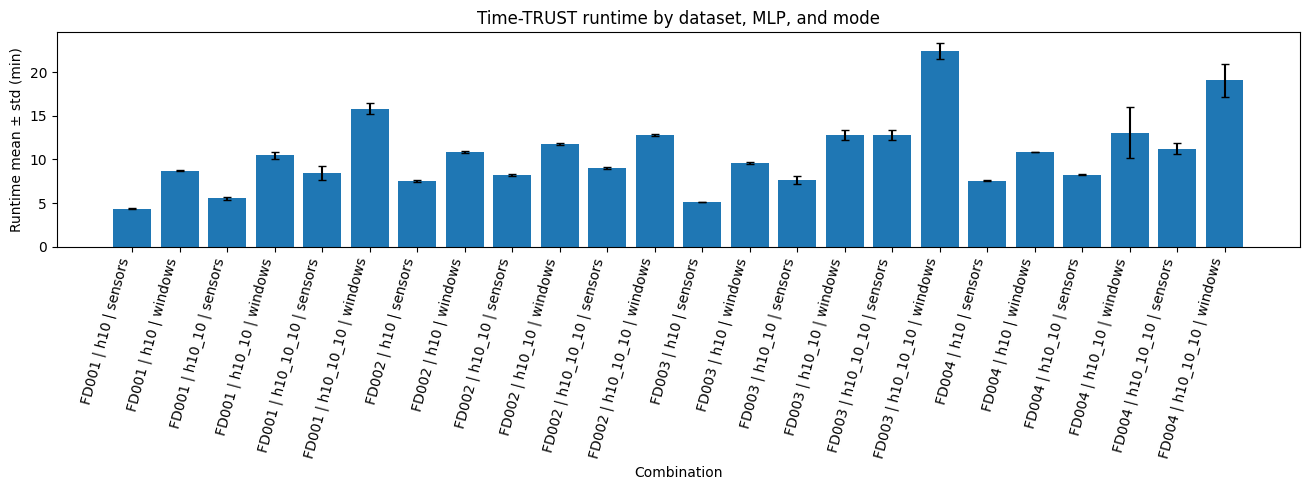

Guardada: results/time_trust_stability_lowrul/notebook_exports/runtime_mean_std_by_combo.png


In [4]:
plot_df = runtime.copy()
plot_df["combo"] = plot_df["dataset"].astype(str) + " | " + plot_df["hidden_tag"].astype(str) + " | " + plot_df["mode"].astype(str)
plot_df = plot_df.sort_values(["dataset", "hidden_tag", "mode"])

x = np.arange(len(plot_df))
plt.figure(figsize=(max(10, len(plot_df) * 0.55), 5))
plt.bar(x, plot_df["runtime_mean_min"], yerr=plot_df["runtime_std_min"], capsize=3)
plt.xticks(x, plot_df["combo"], rotation=75, ha="right")
plt.ylabel("Runtime mean ± std (min)")
plt.xlabel("Combination")
plt.title("Time-TRUST runtime by dataset, MLP, and mode")
plt.tight_layout()
fig_path = OUT_DIR / "runtime_mean_std_by_combo.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Guardada:", fig_path)

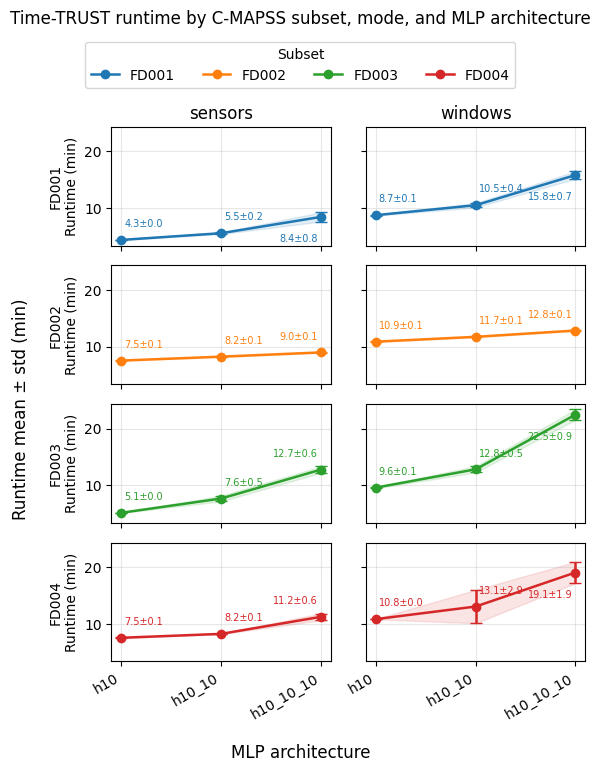

Guardada: results/time_trust_stability_lowrul/notebook_exports/runtime_grid_subset_rows_mode_columns.png


In [21]:
# Runtime by MLP architecture
# Grid layout:
#   rows    = C-MAPSS subset: FD001 / FD002 / FD003 / FD004
#   columns = Time-TRUST mode: sensors / windows
#
# Each panel shows runtime mean ± std across draws.
# The subset color is kept consistent across rows.

plot_df = runtime.copy()

required_cols = [
    "dataset", "hidden_tag", "mode",
    "runtime_mean_min", "runtime_std_min"
]
missing = [c for c in required_cols if c not in plot_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

hidden_order = ["h10", "h10_10", "h10_10_10"]
dataset_order = ["FD001", "FD002", "FD003", "FD004"]
mode_order = ["sensors", "windows"]

# Matplotlib default color cycle, fixed by subset
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
dataset_colors = {
    dataset: default_colors[i % len(default_colors)]
    for i, dataset in enumerate(dataset_order)
}

plot_df["hidden_tag"] = pd.Categorical(
    plot_df["hidden_tag"],
    categories=hidden_order,
    ordered=True
)
plot_df["dataset"] = pd.Categorical(
    plot_df["dataset"],
    categories=dataset_order,
    ordered=True
)
plot_df["mode"] = pd.Categorical(
    plot_df["mode"],
    categories=mode_order,
    ordered=True
)

plot_df = plot_df.sort_values(["dataset", "mode", "hidden_tag"])

fig, axes = plt.subplots(
    nrows=len(dataset_order),
    ncols=len(mode_order),
    figsize=(6, 7.2),   # antes 11, 12
    sharex=True,
    sharey=True
)

x = np.arange(len(hidden_order))

for row_idx, dataset in enumerate(dataset_order):
    for col_idx, mode in enumerate(mode_order):
        ax = axes[row_idx, col_idx]
        
        d = plot_df[
            (plot_df["dataset"] == dataset) &
            (plot_df["mode"] == mode)
        ].copy()
        
        d = (
            d.set_index("hidden_tag")
             .reindex(hidden_order)
             .reset_index()
        )
        
        y = d["runtime_mean_min"].astype(float).to_numpy()
        yerr = d["runtime_std_min"].astype(float).to_numpy()
        color = dataset_colors[dataset]
        
        ax.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            capsize=4,
            linewidth=1.8,
            color=color,
            ecolor=color,
            label=dataset
        )
        
        # Optional light std band between mean - std and mean + std
        valid = np.isfinite(y) & np.isfinite(yerr)
        if valid.sum() >= 2:
            ax.fill_between(
                x[valid],
                (y - yerr)[valid],
                (y + yerr)[valid],
                color=color,
                alpha=0.12
            )
        
        # Dynamic mean ± std labels near points
        ymin, ymax = ax.get_ylim()
        yrange = ymax - ymin

        for xi, yi, ei in zip(x, y, yerr):
            if np.isfinite(yi):
                label = f"{yi:.1f}±{ei:.1f}"
                
                err = ei if np.isfinite(ei) else 0
                upper_with_err = yi + err
                
                near_top = upper_with_err > ymin + 0.82 * yrange
                near_right = xi == x.max()
                
                if near_top and near_right:
                    xytext = (-2, -12)
                    va = "top"
                    ha = "right"
                elif near_top:
                    xytext = (2, -12)
                    va = "top"
                    ha = "left"
                elif near_right:
                    xytext = (-2, 8)
                    va = "bottom"
                    ha = "right"
                else:
                    xytext = (2, 8)
                    va = "bottom"
                    ha = "left"
                
                ax.annotate(
                    label,
                    xy=(xi, yi),
                    xytext=xytext,
                    textcoords="offset points",
                    fontsize=7,
                    color=color,
                    va=va,
                    ha=ha,
                    clip_on=True
                )
        
        if row_idx == 0:
            ax.set_title(str(mode))
        
        if col_idx == 0:
            ax.set_ylabel(f"{dataset}\nRuntime (min)")
        
        ax.set_xticks(x)
        ax.set_xticklabels(hidden_order, rotation=30, ha="right")
        ax.grid(True, alpha=0.3)

# One legend for subset colors
legend_handles = [
    plt.Line2D(
        [0], [0],
        color=dataset_colors[dataset],
        marker="o",
        linewidth=1.8,
        label=dataset
    )
    for dataset in dataset_order
]

fig.legend(
    handles=legend_handles,
    title="Subset",
    loc="upper center",
    ncol=len(dataset_order),
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    "Time-TRUST runtime by C-MAPSS subset, mode, and MLP architecture",
    y=1.055
)

fig.supxlabel("MLP architecture")
fig.supylabel("Runtime mean ± std (min)")

fig.tight_layout(rect=[0, 0, 1, 0.99])

fig_path = OUT_DIR / "runtime_grid_subset_rows_mode_columns.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Guardada:", fig_path)

## 4. Runtime agregado por modo

In [12]:
mode_summary = runtime.groupby("mode", dropna=False).agg(
    combinations=("runtime_mean_seconds", "count"),
    total_ok_runs=("n_ok", "sum"),
    mean_runtime_s=("runtime_mean_seconds", "mean"),
    std_runtime_s=("runtime_mean_seconds", "std"),
    median_runtime_s=("runtime_mean_seconds", "median"),
    mean_cv=("runtime_cv", "mean"),
).reset_index()
mode_summary["mean_runtime_min"] = mode_summary["mean_runtime_s"] / 60
mode_summary["std_runtime_min"] = mode_summary["std_runtime_s"] / 60
mode_summary.to_csv(OUT_DIR / "runtime_by_mode_summary.csv", index=False)
mode_summary

,mode,combinations,total_ok_runs,mean_runtime_s,std_runtime_s,median_runtime_s,mean_cv,mean_runtime_min,std_runtime_min
0,sensors,12,60,477.224671,142.928924,475.428924,0.029061,7.953745,2.382149
1,windows,12,60,790.830437,243.420139,735.463885,0.045060,13.180507,4.057002


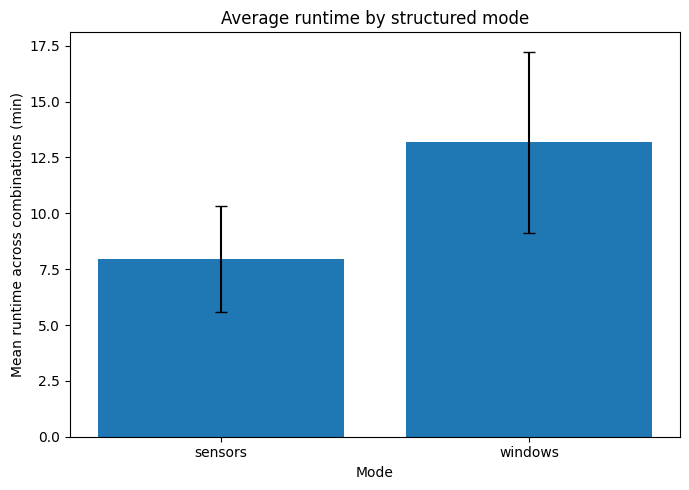

Guardada: results/time_trust_stability_lowrul/notebook_exports/runtime_by_mode.png


In [13]:
x = np.arange(len(mode_summary))
plt.figure(figsize=(7, 5))
plt.bar(x, mode_summary["mean_runtime_min"], yerr=mode_summary["std_runtime_min"], capsize=4)
plt.xticks(x, mode_summary["mode"])
plt.ylabel("Mean runtime across combinations (min)")
plt.xlabel("Mode")
plt.title("Average runtime by structured mode")
plt.tight_layout()
fig_path = OUT_DIR / "runtime_by_mode.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Guardada:", fig_path)

## 5. Cargar estabilidad de selección por \(n_0\)

In [14]:
stab_path = POSTHOC_DIR / "selection_stability_by_n0.csv"
if not stab_path.exists():
    raise FileNotFoundError(f"No existe {stab_path}. Corre primero analyze_trust_selection_stability.py.")

stab_n0 = pd.read_csv(stab_path)
for c in ["n0_value", "n_runs", "mean_selected_count", "mean_pairwise_jaccard", "min_pairwise_jaccard", "max_pairwise_jaccard"]:
    if c in stab_n0.columns:
        stab_n0[c] = pd.to_numeric(stab_n0[c], errors="coerce")

if "hidden_tag" not in stab_n0.columns:
    stab_n0["hidden_tag"] = "h" + stab_n0["hidden"].astype(str).str.replace(" ", "_", regex=False)

stab_n0 = stab_n0.sort_values(["dataset", "hidden_tag", "mode", "bin", "n0_value"]).reset_index(drop=True)
stab_n0.to_csv(OUT_DIR / "selection_stability_by_n0_consolidated.csv", index=False)
stab_n0.head(20)

,dataset,window_tag,hidden,mode,bin,draw_source,n0_value,n_runs,mean_selected_count,mean_pairwise_jaccard,min_pairwise_jaccard,max_pairwise_jaccard,hidden_tag
0,FD001,W30_step1,10,sensors,low,train,1,5,1.0,0.100000,0.000000,1.000000,h10
1,FD001,W30_step1,10,sensors,low,train,2,5,2.0,0.433333,0.000000,1.000000,h10
2,FD001,W30_step1,10,sensors,low,train,3,5,3.0,0.470000,0.200000,1.000000,h10
3,FD001,W30_step1,10,sensors,low,train,4,5,4.0,0.586667,0.333333,1.000000,h10
4,FD001,W30_step1,10,sensors,low,train,5,5,5.0,0.586905,0.250000,1.000000,h10
5,FD001,W30_step1,10,sensors,low,train,6,5,6.0,0.597619,0.333333,1.000000,h10
6,FD001,W30_step1,10,sensors,low,train,7,5,7.0,0.607778,0.400000,1.000000,h10
7,FD001,W30_step1,10,sensors,low,train,8,5,8.0,0.579798,0.333333,0.777778,h10
8,FD001,W30_step1,10,sensors,low,train,9,5,9.0,0.630280,0.384615,0.800000,h10
9,FD001,W30_step1,10,sensors,low,train,10,5,10.0,0.729604,0.538462,0.818182,h10


## 6. Curvas de estabilidad por \(n_0\)

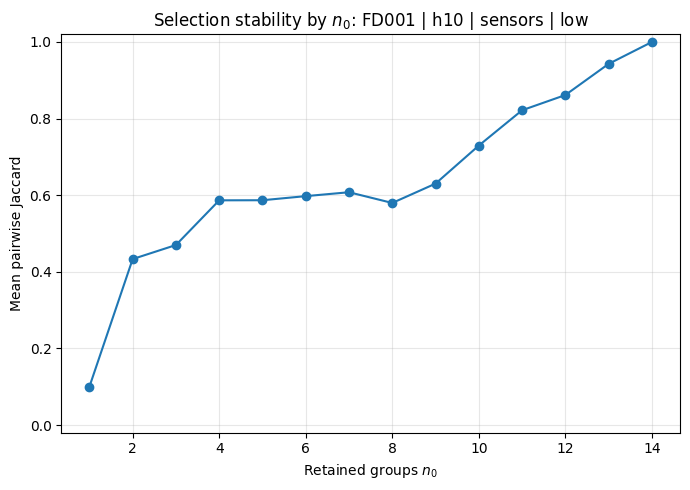

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD001_h10_sensors_low.png


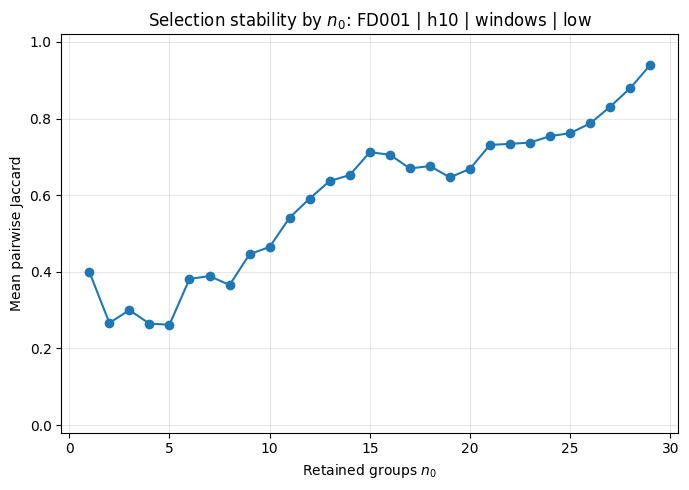

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD001_h10_windows_low.png


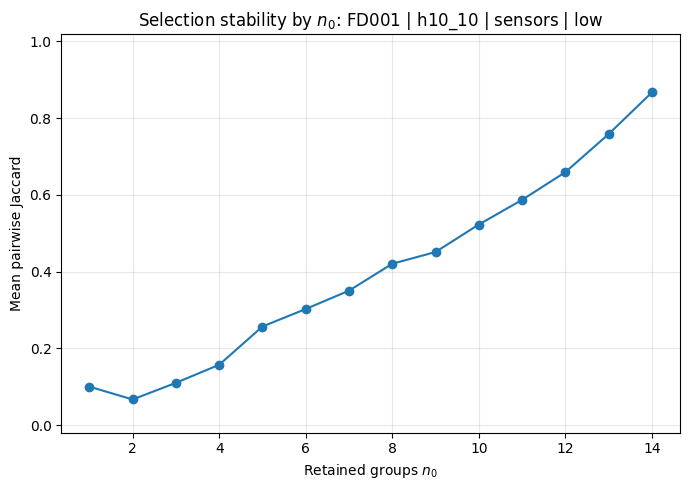

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD001_h10_10_sensors_low.png


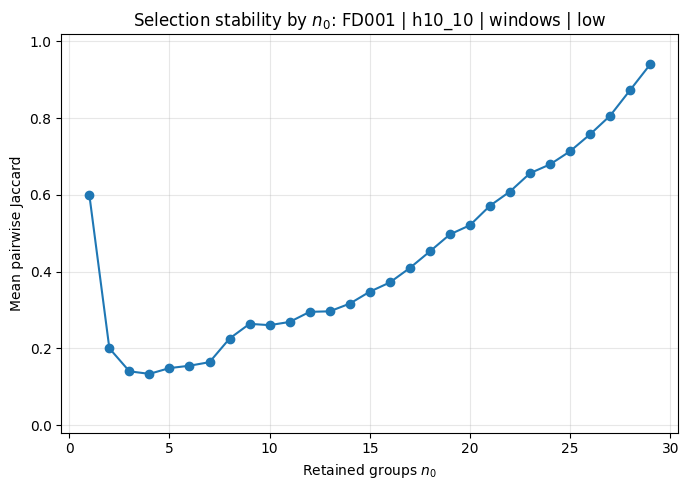

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD001_h10_10_windows_low.png


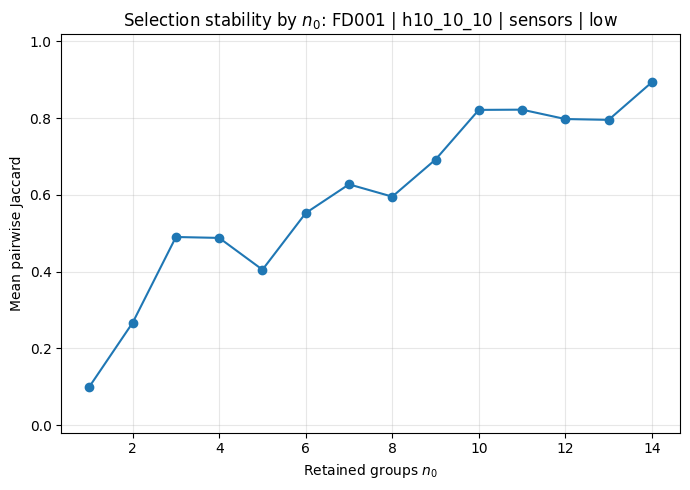

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD001_h10_10_10_sensors_low.png


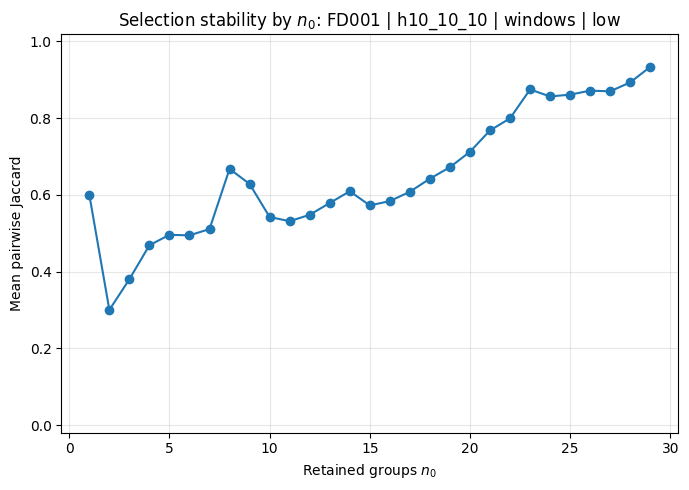

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD001_h10_10_10_windows_low.png


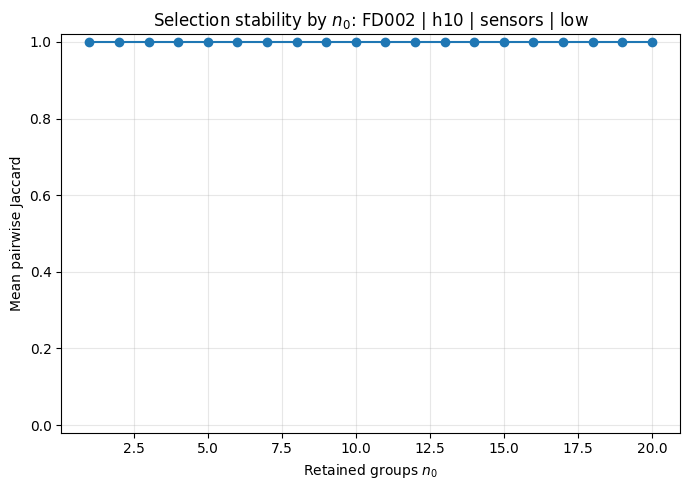

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD002_h10_sensors_low.png


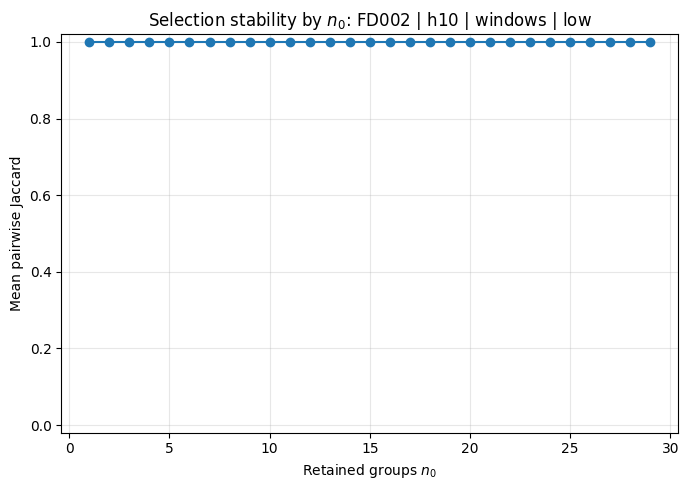

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD002_h10_windows_low.png


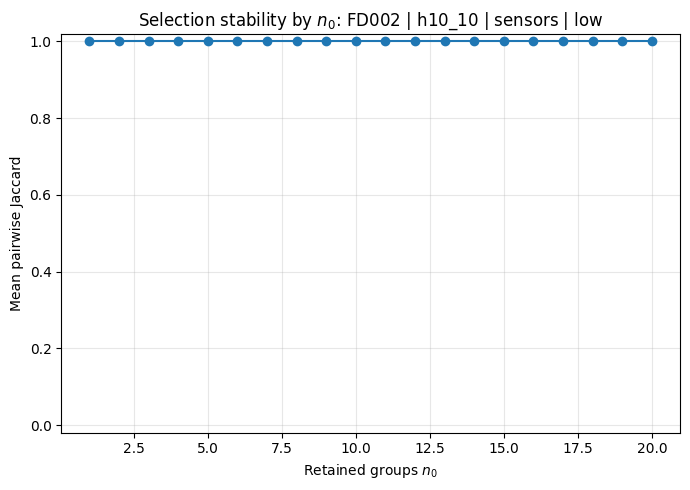

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD002_h10_10_sensors_low.png


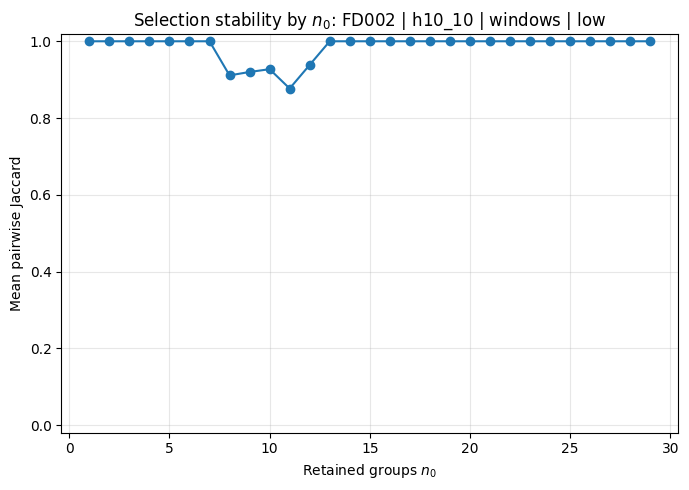

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD002_h10_10_windows_low.png


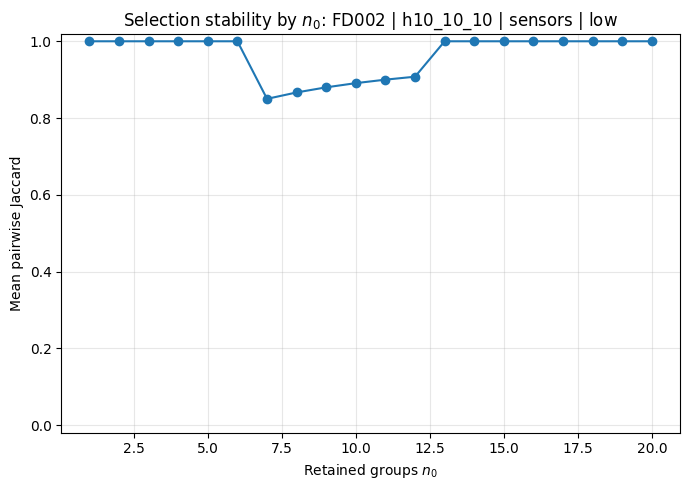

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD002_h10_10_10_sensors_low.png


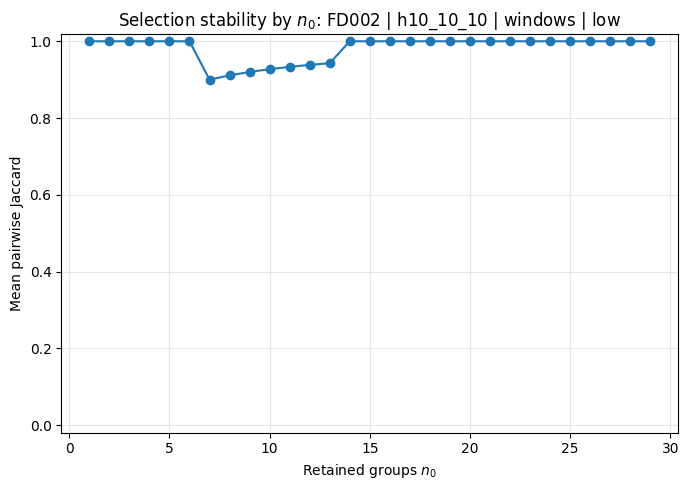

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD002_h10_10_10_windows_low.png


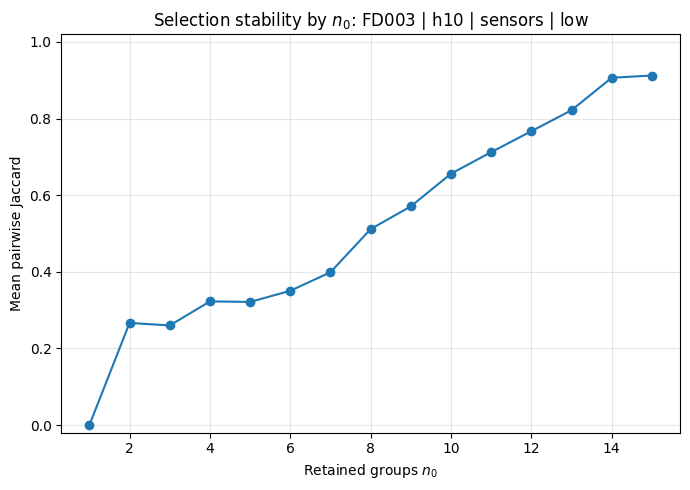

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD003_h10_sensors_low.png


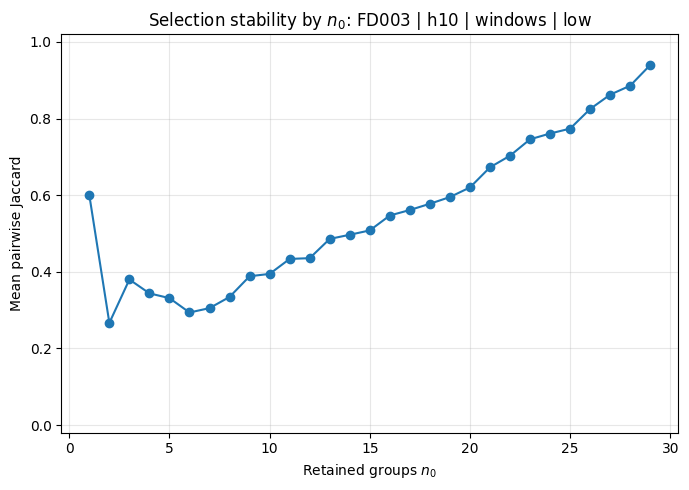

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD003_h10_windows_low.png


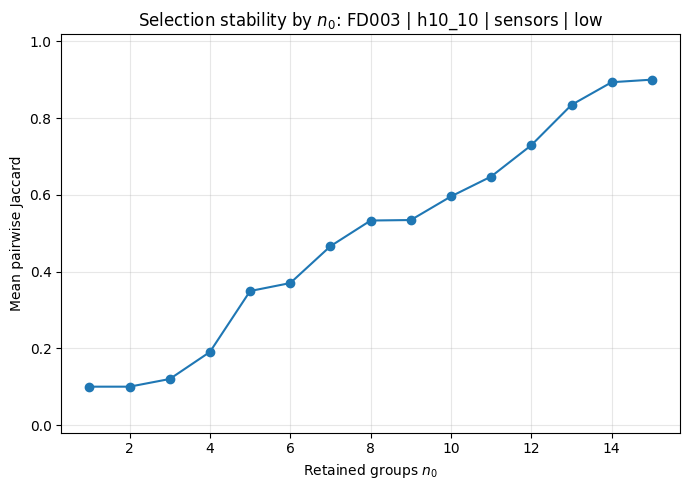

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD003_h10_10_sensors_low.png


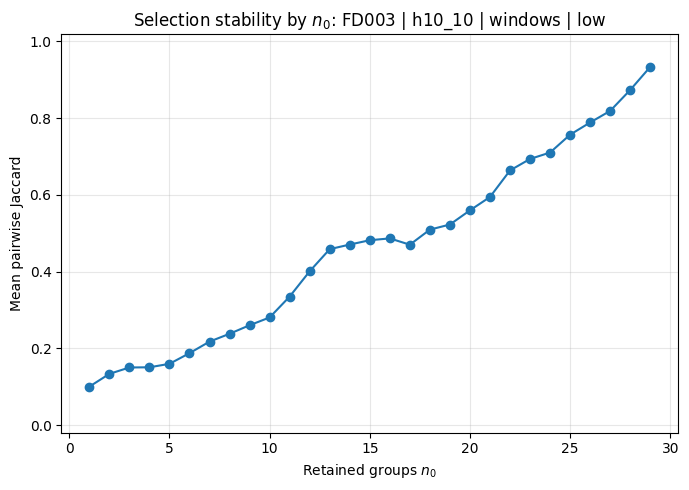

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD003_h10_10_windows_low.png


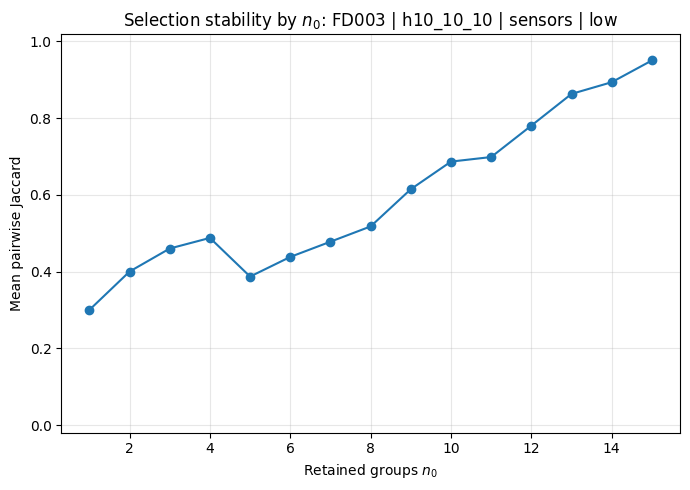

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD003_h10_10_10_sensors_low.png


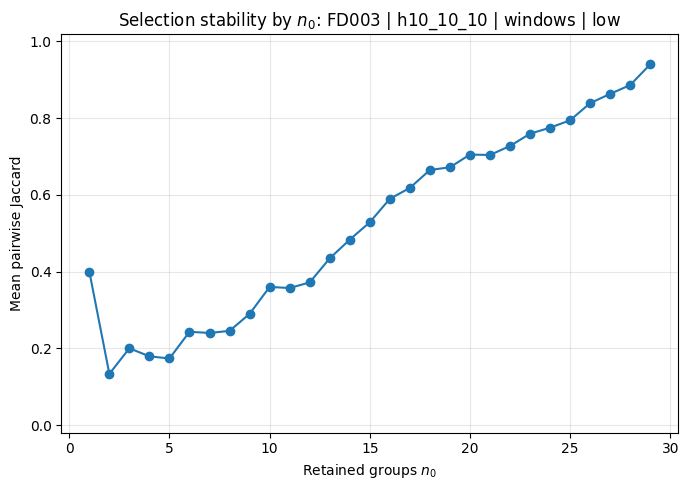

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD003_h10_10_10_windows_low.png


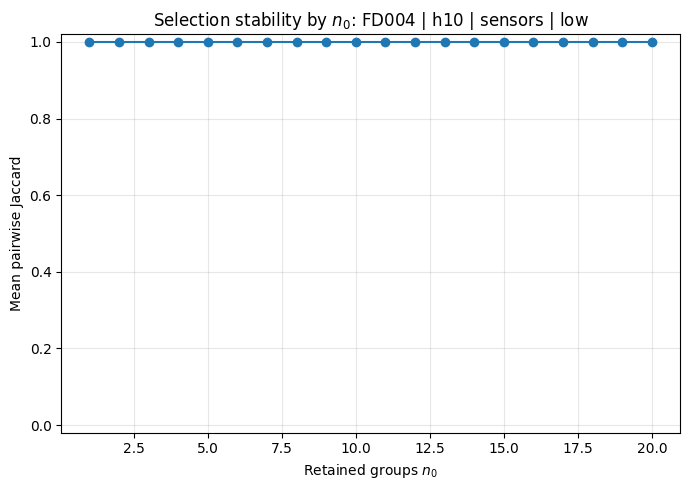

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD004_h10_sensors_low.png


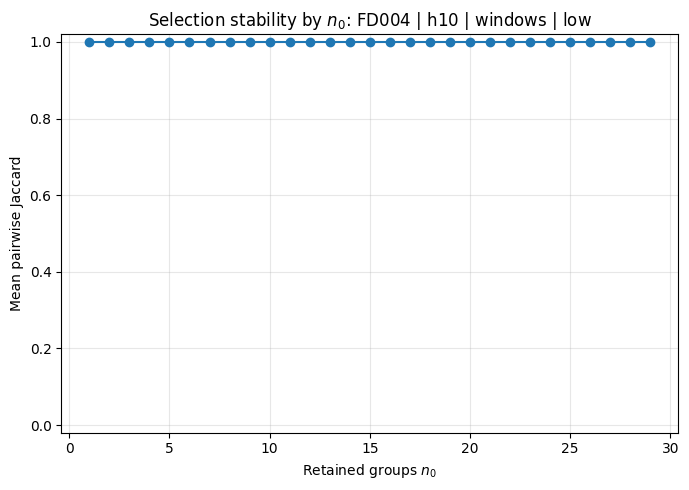

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD004_h10_windows_low.png


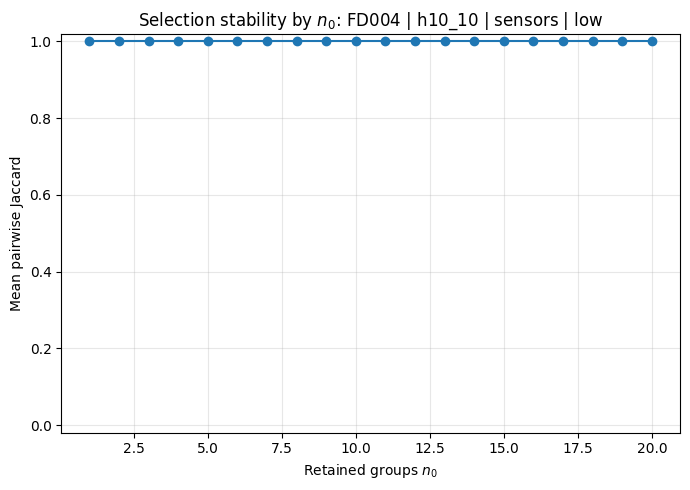

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD004_h10_10_sensors_low.png


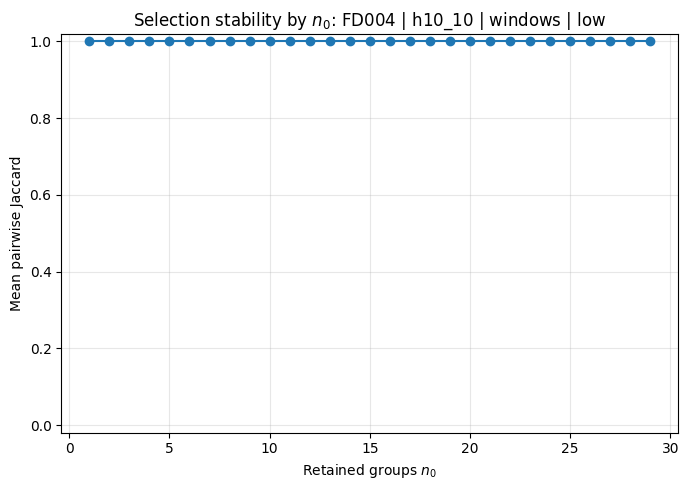

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD004_h10_10_windows_low.png


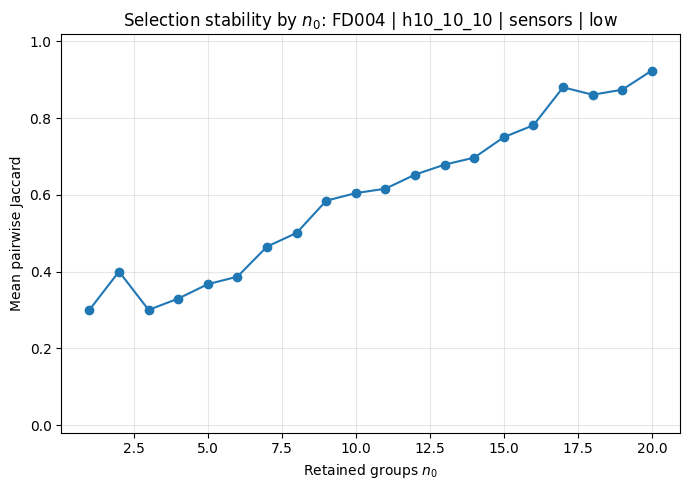

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD004_h10_10_10_sensors_low.png


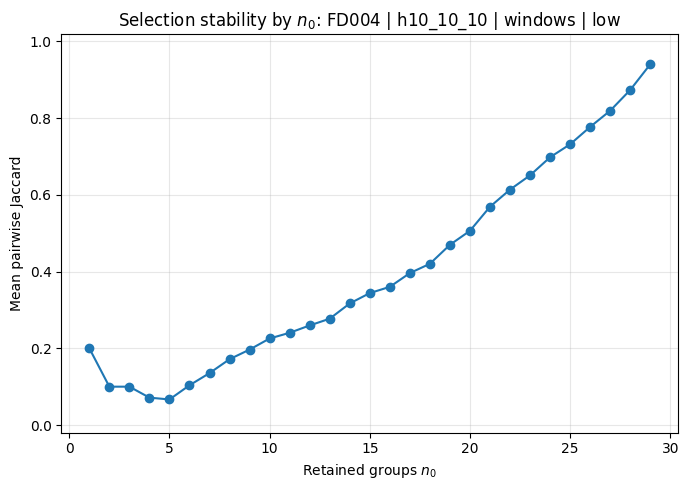

Guardada: results/time_trust_stability_lowrul/notebook_exports/stability_curves_by_n0/stability_by_n0_FD004_h10_10_10_windows_low.png


In [15]:
curve_dir = OUT_DIR / "stability_curves_by_n0"
curve_dir.mkdir(parents=True, exist_ok=True)

for (dataset, hidden_tag, mode, bin_name), g in stab_n0.groupby(["dataset", "hidden_tag", "mode", "bin"], dropna=False):
    g = g.sort_values("n0_value")
    plt.figure(figsize=(7, 5))
    plt.plot(g["n0_value"], g["mean_pairwise_jaccard"], marker="o")
    plt.xlabel("Retained groups $n_0$")
    plt.ylabel("Mean pairwise Jaccard")
    plt.title(f"Selection stability by $n_0$: {dataset} | {hidden_tag} | {mode} | {bin_name}")
    plt.ylim(-0.02, 1.02)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fig_path = curve_dir / f"stability_by_n0_{dataset}_{hidden_tag}_{mode}_{bin_name}.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Guardada:", fig_path)

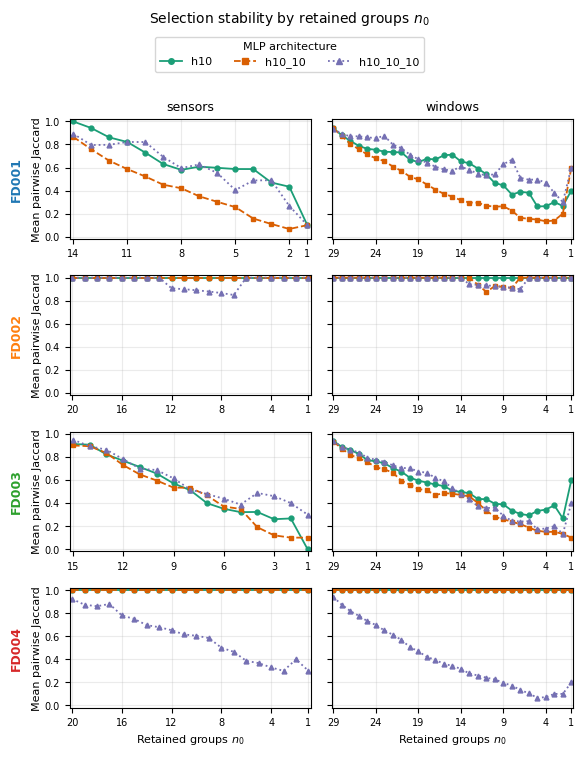

Guardada: results/time_trust_stability_lowrul/notebook_exports/selection_stability_grid_subset_rows_integer_xticks_compact.png
Guardada: results/time_trust_stability_lowrul/notebook_exports/selection_stability_grid_subset_rows_integer_xticks_compact.pdf


In [22]:
# Selection-stability curves by n0
# Grid layout:
#   rows    = C-MAPSS subset
#   columns = Time-TRUST mode
#
# Within each panel:
#   curves = MLP architecture
#
# X-axis is inverted: from largest n0 to smallest n0.
# The subset name is shown in its corresponding color.
# MLP architectures use a separate color palette.
# Each panel has its own integer x-axis ticks, but only a reduced subset is shown.

plot_df = stab_n0.copy()

required_cols = [
    "dataset", "hidden_tag", "mode", "bin",
    "n0_value", "mean_pairwise_jaccard"
]
missing = [c for c in required_cols if c not in plot_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

dataset_order = ["FD001", "FD002", "FD003", "FD004"]
hidden_order = ["h10", "h10_10", "h10_10_10"]
mode_order = ["sensors", "windows"]

# Keep only low-RUL bin if present
if "low" in plot_df["bin"].astype(str).unique():
    plot_df = plot_df[plot_df["bin"].astype(str) == "low"].copy()

plot_df["dataset"] = pd.Categorical(plot_df["dataset"], categories=dataset_order, ordered=True)
plot_df["hidden_tag"] = pd.Categorical(plot_df["hidden_tag"], categories=hidden_order, ordered=True)
plot_df["mode"] = pd.Categorical(plot_df["mode"], categories=mode_order, ordered=True)

plot_df = plot_df.sort_values(["dataset", "mode", "hidden_tag", "n0_value"])

# -----------------------------
# Colors for subsets (used only for row labels / subset identity)
# -----------------------------
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
dataset_colors = {
    dataset: default_colors[i % len(default_colors)]
    for i, dataset in enumerate(dataset_order)
}

# -----------------------------
# Separate colors for MLP architectures
# -----------------------------
hidden_colors = {
    "h10": "#1b9e77",       # teal
    "h10_10": "#d95f02",    # orange
    "h10_10_10": "#7570b3"  # purple
}

# Line style / marker for MLP architecture
hidden_styles = {
    "h10": {"linestyle": "-",  "marker": "o"},
    "h10_10": {"linestyle": "--", "marker": "s"},
    "h10_10_10": {"linestyle": ":", "marker": "^"},
}

fig, axes = plt.subplots(
    nrows=len(dataset_order),
    ncols=len(mode_order),
    figsize=(6, 7.2), 
    sharey=True
)

for row_idx, dataset in enumerate(dataset_order):
    for col_idx, mode in enumerate(mode_order):
        ax = axes[row_idx, col_idx]
        
        panel_df = plot_df[
            (plot_df["dataset"] == dataset) &
            (plot_df["mode"] == mode)
        ].copy()
        
        panel_n0_values = []

        for hidden_tag in hidden_order:
            g = panel_df[panel_df["hidden_tag"] == hidden_tag].copy()
            if g.empty:
                continue
            
            g = g.sort_values("n0_value", ascending=False)
            style = hidden_styles[hidden_tag]
            color = hidden_colors[hidden_tag]

            panel_n0_values.extend(g["n0_value"].dropna().astype(int).tolist())
            
            ax.plot(
                g["n0_value"],
                g["mean_pairwise_jaccard"],
                color=color,
                linestyle=style["linestyle"],
                marker=style["marker"],
                linewidth=1.3,
                markersize=3.5,
                label=hidden_tag
            )
        
        if row_idx == 0:
            ax.set_title(mode, fontsize=9)
        
        # Left column: y-axis label + colored subset name, closer together
        if col_idx == 0:
            ax.set_ylabel("Mean pairwise Jaccard", fontsize=8, labelpad=2)
            ax.text(
                -0.22, 0.5, dataset,   # closer than before
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=9,
                fontweight="bold",
                color=dataset_colors[dataset]
            )
        
        ax.set_ylim(-0.02, 1.02)
        ax.grid(True, alpha=0.25)
        ax.tick_params(axis="both", labelsize=7)

        # Panel-specific integer x ticks, but reduced so they do not look crowded
        if panel_n0_values:
            max_n0 = max(panel_n0_values)
            min_n0 = min(panel_n0_values)
            xticks_all = list(range(max_n0, min_n0 - 1, -1))

            # Show at most around 6 ticks
            max_ticks_to_show = 6
            step = max(1, int(np.ceil(len(xticks_all) / max_ticks_to_show)))
            xticks_shown = xticks_all[::step]

            # Ensure min and max are shown
            if xticks_all[-1] not in xticks_shown:
                xticks_shown.append(xticks_all[-1])
            xticks_shown = sorted(set(xticks_shown), reverse=True)

            ax.set_xticks(xticks_shown)
            ax.set_xlim(max_n0 + 0.2, min_n0 - 0.2)

        # Show x-label only on bottom row
        if row_idx == len(dataset_order) - 1:
            ax.set_xlabel("Retained groups $n_0$", fontsize=8)

# One legend for MLP architectures
legend_handles = [
    plt.Line2D(
        [0], [0],
        color=hidden_colors[h],
        linestyle=hidden_styles[h]["linestyle"],
        marker=hidden_styles[h]["marker"],
        linewidth=1.3,
        markersize=4,
        label=h
    )
    for h in hidden_order
]

fig.legend(
    handles=legend_handles,
    title="MLP architecture",
    loc="upper center",
    ncol=len(hidden_order),
    bbox_to_anchor=(0.5, 1.015),
    fontsize=8,
    title_fontsize=8
)

fig.suptitle(
    "Selection stability by retained groups $n_0$",
    y=1.045,
    fontsize=10
)

fig.tight_layout(rect=[0.02, 0, 1, 0.985])

fig_path = OUT_DIR / "selection_stability_grid_subset_rows_integer_xticks_compact.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
fig.savefig(OUT_DIR / "selection_stability_grid_subset_rows_integer_xticks_compact.pdf", bbox_inches="tight")
plt.show()

print("Guardada:", fig_path)
print("Guardada:", OUT_DIR / "selection_stability_grid_subset_rows_integer_xticks_compact.pdf")

In [32]:
from pathlib import Path
import numpy as np
import pandas as pd

processed_root = Path("datasets/processed")
window_tag = "W30_step1"
datasets = ["FD001", "FD002", "FD003", "FD004"]

rows = []
for ds in datasets:
    data = np.load(processed_root / ds / window_tag / "dataset.npz", allow_pickle=True)
    y_train = data["y_train"].reshape(-1)
    y_val = data["y_val"].reshape(-1)

    rows.append({
        "dataset": ds,
        "train_total": len(y_train),
        "train_low_0_30": int(((y_train >= 0) & (y_train < 30)).sum()),
        "val_total": len(y_val),
        "val_low_0_30": int(((y_val >= 0) & (y_val < 30)).sum()),
        "train_low_fraction": float(((y_train >= 0) & (y_train < 30)).mean()),
        "val_low_fraction": float(((y_val >= 0) & (y_val < 30)).mean()),
    })

low_counts = pd.DataFrame(rows)
low_counts

,dataset,train_total,train_low_0_30,val_total,val_low_0_30,train_low_fraction,val_low_fraction
0,FD001,15843,2700,1888,300,0.170422,0.158898
1,FD002,41513,7020,4706,780,0.169104,0.165746
2,FD003,19620,2700,2200,300,0.137615,0.136364
3,FD004,48596,6750,5432,720,0.138900,0.132548


In [33]:
import json
from pathlib import Path
import pandas as pd
import itertools
import numpy as np

runs_files = sorted(Path("results/time_trust_stability_lowrul").rglob("runs.csv"))

runs_all = []
for f in runs_files:
    df = pd.read_csv(f)
    df["runs_csv"] = str(f)
    runs_all.append(df)

runs_all = pd.concat(runs_all, ignore_index=True)

def parse_indices(x):
    try:
        return set(json.loads(x))
    except Exception:
        return set()

rows = []
for key, g in runs_all.groupby(["dataset", "hidden", "mode", "bin"], dropna=False):
    batch_sets = []
    for _, r in g.iterrows():
        if str(r.get("status")) == "ok":
            batch_sets.append(parse_indices(r["batch_indices_json"]))

    scores = []
    for a, b in itertools.combinations(batch_sets, 2):
        if len(a | b) > 0:
            scores.append(len(a & b) / len(a | b))

    rows.append({
        "dataset": key[0],
        "hidden": key[1],
        "mode": key[2],
        "bin": key[3],
        "n_ok_draws": len(batch_sets),
        "mean_batch_jaccard": np.mean(scores) if scores else np.nan,
        "max_batch_jaccard": np.max(scores) if scores else np.nan,
    })

batch_overlap = pd.DataFrame(rows).sort_values(["dataset", "hidden", "mode"])
batch_overlap

,dataset,hidden,mode,bin,n_ok_draws,mean_batch_jaccard,max_batch_jaccard
0,FD001,10,sensors,low,5,0.016819,0.025641
1,FD001,10,windows,low,5,0.016819,0.025641
2,FD001,10 10,sensors,low,5,0.016819,0.025641
3,FD001,10 10,windows,low,5,0.016819,0.025641
4,FD001,10 10 10,sensors,low,5,0.016819,0.025641
5,FD001,10 10 10,windows,low,5,0.016819,0.025641
6,FD002,10,sensors,low,5,0.006594,0.025641
7,FD002,10,windows,low,5,0.006594,0.025641
8,FD002,10 10,sensors,low,5,0.006594,0.025641
9,FD002,10 10,windows,low,5,0.006594,0.025641


In [36]:
sel = pd.read_csv(
    "results/time_trust_stability_lowrul/selection_stability_posthoc/selection_iterations_long.csv"
)

# Example: inspect FD004 h10 sensors
inspect = sel[
    (sel["dataset"] == "FD004") &
    (sel["hidden"] == "10") &
    (sel["mode"] == "sensors")
].sort_values(["n0_value", "draw"])

inspect[["dataset", "hidden", "mode", "draw", "n0_value", "selected_groups_json"]].head(80)

,dataset,hidden,mode,draw,n0_value,selected_groups_json
2059,FD004,10,sensors,0,1,"[""2""]"
2079,FD004,10,sensors,1,1,"[""2""]"
2099,FD004,10,sensors,2,1,"[""2""]"
2119,FD004,10,sensors,3,1,"[""2""]"
2139,FD004,10,sensors,4,1,"[""2""]"
...,...,...,...,...,...,...
2044,FD004,10,sensors,0,16,"[""1"", ""10"", ""11"", ""12"", ""13"", ""14"", ""15"", ""16"", ""2"", ""3"", ""4"", ""5"", ""6"", ""7"", ""8"", ""9""]"
2064,FD004,10,sensors,1,16,"[""1"", ""10"", ""11"", ""12"", ""13"", ""14"", ""15"", ""16"", ""2"", ""3"", ""4"", ""5"", ""6"", ""7"", ""8"", ""9""]"
2084,FD004,10,sensors,2,16,"[""1"", ""10"", ""11"", ""12"", ""13"", ""14"", ""15"", ""16"", ""2"", ""3"", ""4"", ""5"", ""6"", ""7"", ""8"", ""9""]"
2104,FD004,10,sensors,3,16,"[""1"", ""10"", ""11"", ""12"", ""13"", ""14"", ""15"", ""16"", ""2"", ""3"", ""4"", ""5"", ""6"", ""7"", ""8"", ""9""]"


In [37]:
import json
import pandas as pd
from pathlib import Path
import itertools
import numpy as np

runs_files = sorted(Path("results/time_trust_stability_lowrul").rglob("runs.csv"))

runs_all = []
for f in runs_files:
    df = pd.read_csv(f)
    df["runs_csv"] = str(f)
    runs_all.append(df)

runs_all = pd.concat(runs_all, ignore_index=True)

def parse_indices(x):
    try:
        return set(json.loads(x))
    except Exception:
        return set()

rows = []
for key, g in runs_all.groupby(["dataset", "hidden", "mode", "bin"], dropna=False):
    ok = g[g["status"].astype(str) == "ok"].copy()
    batch_sets = [parse_indices(x) for x in ok["batch_indices_json"]]
    
    overlaps = []
    jaccards = []
    for a, b in itertools.combinations(batch_sets, 2):
        inter = len(a & b)
        union = len(a | b)
        overlaps.append(inter)
        jaccards.append(inter / union if union else np.nan)
    
    rows.append({
        "dataset": key[0],
        "hidden": key[1],
        "mode": key[2],
        "bin": key[3],
        "n_ok_draws": len(ok),
        "unique_out_dirs": ok["out_dir"].nunique(),
        "mean_batch_overlap_count": np.nanmean(overlaps) if overlaps else np.nan,
        "max_batch_overlap_count": np.nanmax(overlaps) if overlaps else np.nan,
        "mean_batch_jaccard": np.nanmean(jaccards) if jaccards else np.nan,
        "max_batch_jaccard": np.nanmax(jaccards) if jaccards else np.nan,
    })

batch_overlap = pd.DataFrame(rows).sort_values(["dataset", "hidden", "mode"])
batch_overlap

,dataset,hidden,mode,bin,n_ok_draws,unique_out_dirs,mean_batch_overlap_count,max_batch_overlap_count,mean_batch_jaccard,max_batch_jaccard
0,FD001,10,sensors,low,5,5,3.3,5,0.016819,0.025641
1,FD001,10,windows,low,5,5,3.3,5,0.016819,0.025641
2,FD001,10 10,sensors,low,5,5,3.3,5,0.016819,0.025641
3,FD001,10 10,windows,low,5,5,3.3,5,0.016819,0.025641
4,FD001,10 10 10,sensors,low,5,5,3.3,5,0.016819,0.025641
5,FD001,10 10 10,windows,low,5,5,3.3,5,0.016819,0.025641
6,FD002,10,sensors,low,5,5,1.3,5,0.006594,0.025641
7,FD002,10,windows,low,5,5,1.3,5,0.006594,0.025641
8,FD002,10 10,sensors,low,5,5,1.3,5,0.006594,0.025641
9,FD002,10 10,windows,low,5,5,1.3,5,0.006594,0.025641


In [38]:
batch_overlap[["dataset", "hidden", "mode", "bin", "n_ok_draws", "unique_out_dirs", "mean_batch_jaccard"]]

,dataset,hidden,mode,bin,n_ok_draws,unique_out_dirs,mean_batch_jaccard
0,FD001,10,sensors,low,5,5,0.016819
1,FD001,10,windows,low,5,5,0.016819
2,FD001,10 10,sensors,low,5,5,0.016819
3,FD001,10 10,windows,low,5,5,0.016819
4,FD001,10 10 10,sensors,low,5,5,0.016819
5,FD001,10 10 10,windows,low,5,5,0.016819
6,FD002,10,sensors,low,5,5,0.006594
7,FD002,10,windows,low,5,5,0.006594
8,FD002,10 10,sensors,low,5,5,0.006594
9,FD002,10 10,windows,low,5,5,0.006594


## 7. Resumen de estabilidad a sparsity moderada

In [23]:
def summarize_stability_curve(g: pd.DataFrame) -> pd.Series:
    g = g.dropna(subset=["n0_value", "mean_pairwise_jaccard"]).copy()
    if g.empty:
        return pd.Series({
            "max_n0": np.nan,
            "final_jaccard_n0_1": np.nan,
            "moderate_jaccard_ge_50pct": np.nan,
            "high_retention_jaccard_ge_75pct": np.nan,
            "auc_jaccard_all_n0": np.nan,
        })
    max_n0 = g["n0_value"].max()
    final = g.loc[g["n0_value"] == 1, "mean_pairwise_jaccard"]
    moderate = g.loc[g["n0_value"] >= 0.50 * max_n0, "mean_pairwise_jaccard"]
    high = g.loc[g["n0_value"] >= 0.75 * max_n0, "mean_pairwise_jaccard"]
    return pd.Series({
        "max_n0": max_n0,
        "final_jaccard_n0_1": final.mean() if len(final) else np.nan,
        "moderate_jaccard_ge_50pct": moderate.mean() if len(moderate) else np.nan,
        "high_retention_jaccard_ge_75pct": high.mean() if len(high) else np.nan,
        "auc_jaccard_all_n0": g["mean_pairwise_jaccard"].mean(),
    })

stab_summary = (
    stab_n0.groupby(["dataset", "hidden_tag", "hidden", "mode", "bin", "draw_source"], dropna=False)
    .apply(summarize_stability_curve)
    .reset_index()
    .sort_values(["dataset", "hidden_tag", "mode"])
)

stab_summary.to_csv(OUT_DIR / "selection_stability_curve_summary.csv", index=False)
stab_summary

/tmp/ipykernel_4039120/485567446.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_stability_curve)


,dataset,hidden_tag,hidden,mode,bin,draw_source,max_n0,final_jaccard_n0_1,moderate_jaccard_ge_50pct,high_retention_jaccard_ge_75pct,auc_jaccard_all_n0
0,FD001,h10,10,sensors,low,train,14.0,0.1,0.771706,0.906548,0.639155
1,FD001,h10,10,windows,low,train,29.0,0.4,0.749127,0.803241,0.593101
2,FD001,h10_10,10 10,sensors,low,train,14.0,0.1,0.576776,0.717601,0.400513
3,FD001,h10_10,10 10,windows,low,train,29.0,0.6,0.613614,0.754317,0.436900
4,FD001,h10_10_10,10 10 10,sensors,low,train,14.0,0.1,0.755392,0.826932,0.596040
5,FD001,h10_10_10,10 10 10,windows,low,train,29.0,0.6,0.767675,0.869734,0.650646
6,FD002,h10,10,sensors,low,train,20.0,1.0,1.000000,1.000000,1.000000
7,FD002,h10,10,windows,low,train,29.0,1.0,1.000000,1.000000,1.000000
8,FD002,h10_10,10 10,sensors,low,train,20.0,1.0,1.000000,1.000000,1.000000
9,FD002,h10_10,10 10,windows,low,train,29.0,1.0,1.000000,1.000000,0.985302


## 8. Tabla integrada: runtime + estabilidad

In [24]:
runtime_keyed = runtime.copy()
combined = pd.merge(
    runtime_keyed,
    stab_summary,
    on=["dataset", "hidden_tag", "hidden", "mode", "bin"],
    how="left",
    suffixes=("_runtime", "_stability")
)

combined_table = combined[[
    "dataset", "hidden_tag", "mode", "bin",
    "n_runs", "n_ok",
    "runtime_mean_seconds", "runtime_std_seconds", "runtime_cv", "runtime_p95_seconds",
    "final_jaccard_n0_1",
    "moderate_jaccard_ge_50pct",
    "high_retention_jaccard_ge_75pct",
    "auc_jaccard_all_n0",
]].copy()

combined_table = combined_table.rename(columns={
    "hidden_tag": "MLP",
    "mode": "Mode",
    "bin": "RUL bin",
    "n_runs": "Runs",
    "n_ok": "OK runs",
    "runtime_mean_seconds": "Mean runtime (s)",
    "runtime_std_seconds": "Std runtime (s)",
    "runtime_cv": "Runtime CV",
    "runtime_p95_seconds": "P95 runtime (s)",
    "final_jaccard_n0_1": "Jaccard @ final",
    "moderate_jaccard_ge_50pct": "Jaccard @ >=50% groups",
    "high_retention_jaccard_ge_75pct": "Jaccard @ >=75% groups",
    "auc_jaccard_all_n0": "Mean Jaccard over n0",
})

combined_table.to_csv(OUT_DIR / "runtime_plus_selection_stability_table.csv", index=False)
combined_table

,dataset,MLP,Mode,RUL bin,Runs,OK runs,Mean runtime (s),Std runtime (s),Runtime CV,P95 runtime (s),Jaccard @ final,Jaccard @ >=50% groups,Jaccard @ >=75% groups,Mean Jaccard over n0
0,FD001,h10,sensors,low,5,5,260.557002,2.093029,0.008033,263.348784,0.1,0.771706,0.906548,0.639155
1,FD001,h10,windows,low,5,5,522.933974,5.831924,0.011152,528.230996,0.4,0.749127,0.803241,0.593101
2,FD001,h10_10,sensors,low,5,5,331.689352,9.084209,0.027388,342.293062,0.1,0.576776,0.717601,0.400513
3,FD001,h10_10,windows,low,5,5,628.708296,23.109951,0.036758,654.417905,0.6,0.613614,0.754317,0.436900
4,FD001,h10_10_10,sensors,low,5,5,504.245545,48.903612,0.096984,565.753502,0.1,0.755392,0.826932,0.596040
5,FD001,h10_10_10,windows,low,5,5,948.060377,39.169531,0.041315,979.768890,0.6,0.767675,0.869734,0.650646
6,FD002,h10,sensors,low,5,5,451.074819,4.142244,0.009183,453.915015,1.0,1.000000,1.000000,1.000000
7,FD002,h10,windows,low,5,5,651.573692,4.945826,0.007591,656.959833,1.0,1.000000,1.000000,1.000000
8,FD002,h10_10,sensors,low,5,5,492.518346,4.087438,0.008299,496.733644,1.0,1.000000,1.000000,1.000000
9,FD002,h10_10,windows,low,5,5,702.850720,6.486490,0.009229,707.969013,1.0,1.000000,1.000000,0.985302


## 9. Supervivencia de sensores/windows

In [25]:
survival_freq_path = POSTHOC_DIR / "group_survival_frequency.csv"
survival_sim_path = POSTHOC_DIR / "group_survival_similarity.csv"

if not survival_freq_path.exists() or not survival_sim_path.exists():
    raise FileNotFoundError("Faltan archivos de supervivencia. Corre analyze_trust_selection_stability.py.")

survival_freq = pd.read_csv(survival_freq_path)
survival_sim = pd.read_csv(survival_sim_path)

if "hidden_tag" not in survival_freq.columns:
    survival_freq["hidden_tag"] = "h" + survival_freq["hidden"].astype(str).str.replace(" ", "_", regex=False)
if "hidden_tag" not in survival_sim.columns:
    survival_sim["hidden_tag"] = "h" + survival_sim["hidden"].astype(str).str.replace(" ", "_", regex=False)

for c in ["mean_survival_steps", "mean_survival_fraction", "mean_deepest_n0_present"]:
    if c in survival_freq.columns:
        survival_freq[c] = pd.to_numeric(survival_freq[c], errors="coerce")
for c in ["mean_survival_cosine", "mean_survival_pearson", "mean_survival_spearman", "mean_deepest_set_jaccard"]:
    if c in survival_sim.columns:
        survival_sim[c] = pd.to_numeric(survival_sim[c], errors="coerce")

survival_freq.to_csv(OUT_DIR / "group_survival_frequency_consolidated.csv", index=False)
survival_sim.to_csv(OUT_DIR / "group_survival_similarity_consolidated.csv", index=False)
survival_sim.sort_values(["dataset", "hidden_tag", "mode"]).head(30)

,dataset,window_tag,hidden,mode,bin,draw_source,n_runs,n_groups,mean_survival_cosine,mean_survival_pearson,mean_survival_spearman,mean_deepest_set_jaccard,hidden_tag
0,FD001,W30_step1,10,sensors,low,train,5,14,0.923251,0.657582,0.657582,0.1,h10
1,FD001,W30_step1,10,windows,low,train,5,30,0.903168,0.631413,0.631413,0.4,h10
2,FD001,W30_step1,10 10,sensors,low,train,5,15,0.732414,0.030000,0.030000,0.1,h10_10
3,FD001,W30_step1,10 10,windows,low,train,5,30,0.763425,0.099488,0.099488,0.6,h10_10
4,FD001,W30_step1,10 10 10,sensors,low,train,5,15,0.900099,0.637857,0.637857,0.1,h10_10_10
5,FD001,W30_step1,10 10 10,windows,low,train,5,30,0.919135,0.692191,0.692191,0.6,h10_10_10
6,FD002,W30_step1,10,sensors,low,train,5,20,1.000000,1.000000,1.000000,1.0,h10
7,FD002,W30_step1,10,windows,low,train,5,29,1.000000,1.000000,1.000000,1.0,h10
8,FD002,W30_step1,10 10,sensors,low,train,5,20,1.000000,1.000000,1.000000,1.0,h10_10
9,FD002,W30_step1,10 10,windows,low,train,5,29,0.999158,0.996453,0.996453,1.0,h10_10


## 10. Top grupos por supervivencia

In [26]:
top_k = 10
top_survival = (
    survival_freq
    .sort_values(["dataset", "hidden_tag", "mode", "bin", "mean_survival_fraction"],
                 ascending=[True, True, True, True, False])
    .groupby(["dataset", "hidden_tag", "mode", "bin"], dropna=False)
    .head(top_k)
    .reset_index(drop=True)
)

top_survival.to_csv(OUT_DIR / "top_group_survival.csv", index=False)
top_survival.head(80)

,dataset,window_tag,hidden,mode,bin,draw_source,group,n_runs,mean_survival_steps,mean_survival_fraction,mean_deepest_n0_present,hidden_tag
0,FD001,W30_step1,10,sensors,low,train,11,5,12.8,0.914286,2.2,h10
1,FD001,W30_step1,10,sensors,low,train,6,5,12.4,0.885714,2.6,h10
2,FD001,W30_step1,10,sensors,low,train,8,5,11.4,0.814286,3.6,h10
3,FD001,W30_step1,10,sensors,low,train,3,5,10.8,0.771429,4.2,h10
4,FD001,W30_step1,10,sensors,low,train,9,5,9.4,0.671429,5.6,h10
...,...,...,...,...,...,...,...,...,...,...,...,...
75,FD002,W30_step1,10,windows,low,train,6,5,24.0,0.827586,6.0,h10
76,FD002,W30_step1,10,windows,low,train,7,5,23.0,0.793103,7.0,h10
77,FD002,W30_step1,10,windows,low,train,8,5,22.0,0.758621,8.0,h10
78,FD002,W30_step1,10,windows,low,train,9,5,21.0,0.724138,9.0,h10


## 11. Figuras de supervivencia

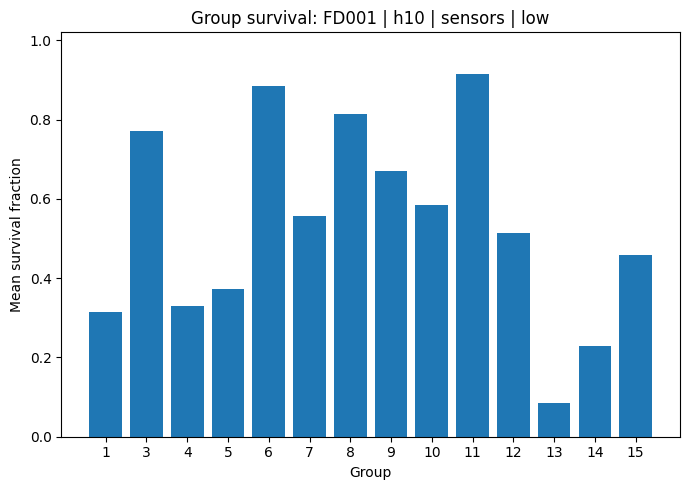

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD001_h10_sensors_low.png


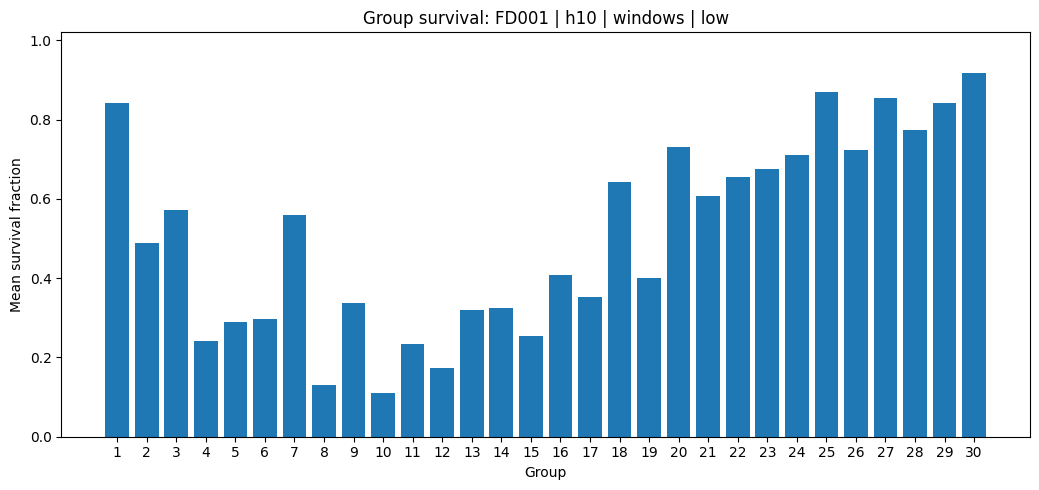

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD001_h10_windows_low.png


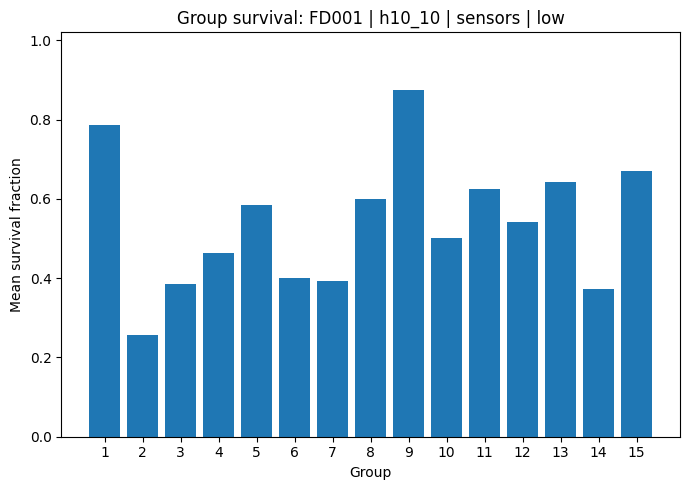

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD001_h10_10_sensors_low.png


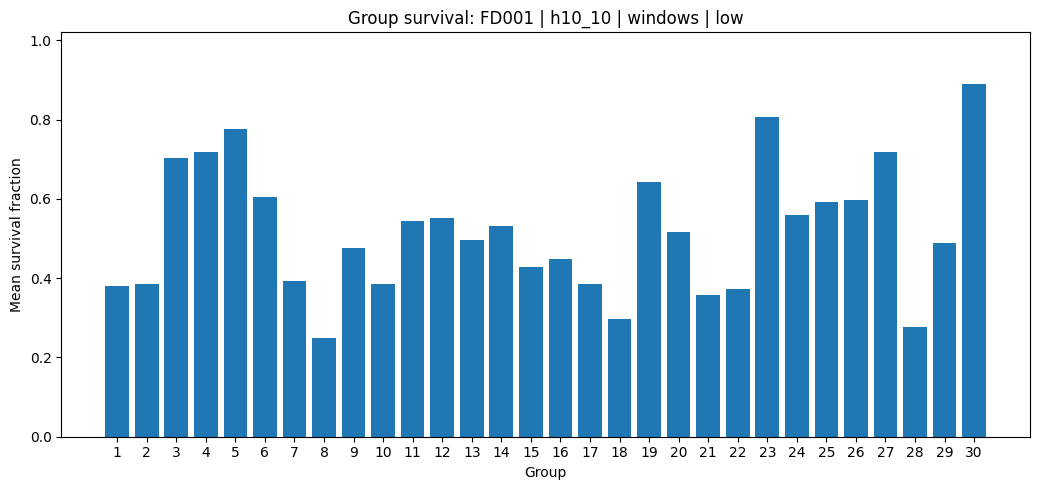

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD001_h10_10_windows_low.png


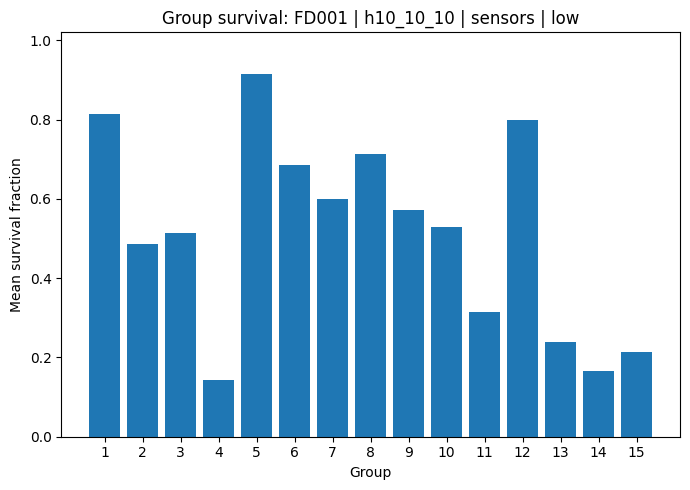

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD001_h10_10_10_sensors_low.png


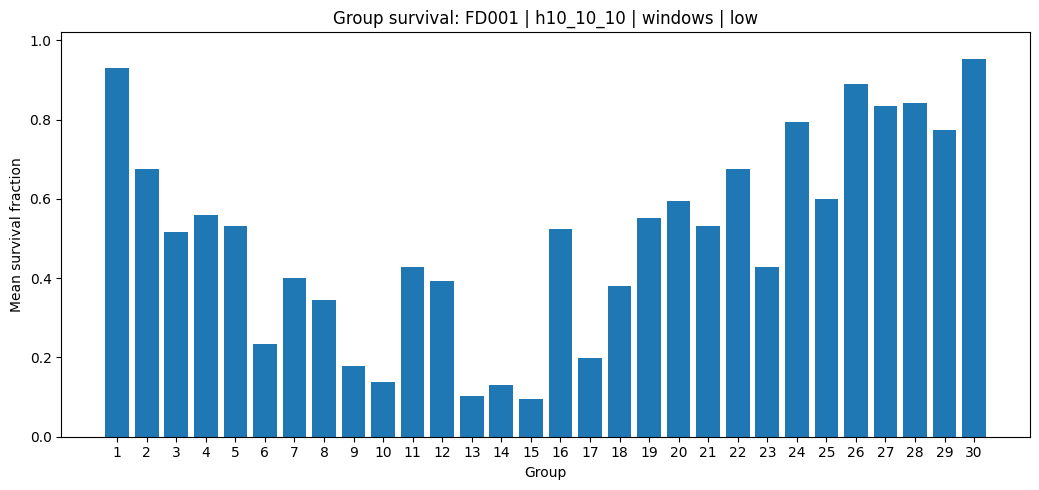

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD001_h10_10_10_windows_low.png


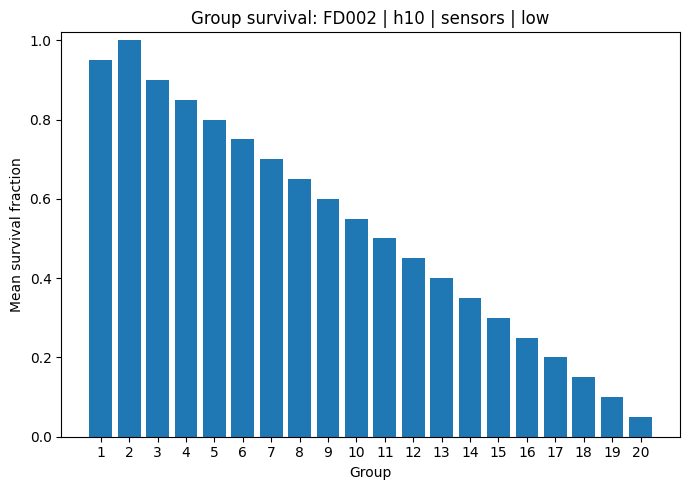

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD002_h10_sensors_low.png


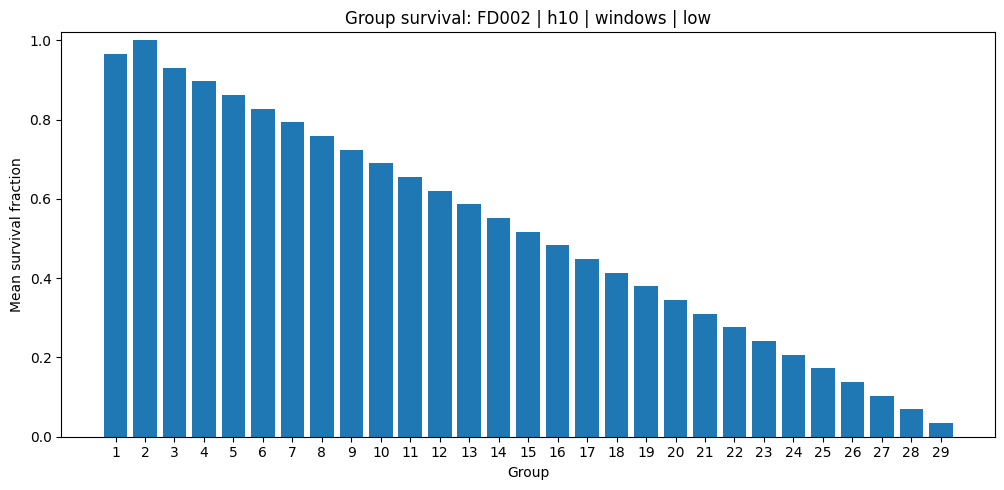

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD002_h10_windows_low.png


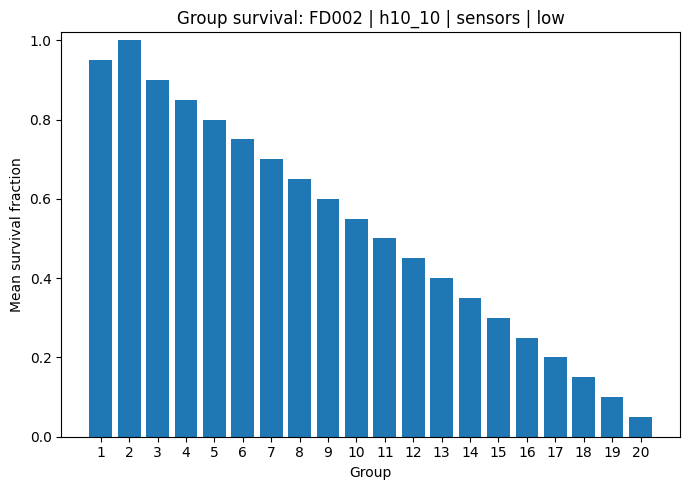

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD002_h10_10_sensors_low.png


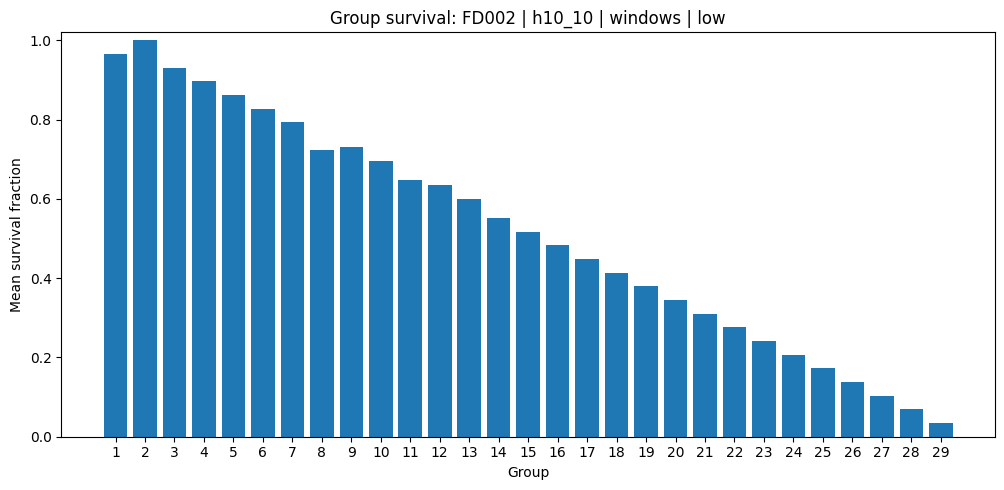

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD002_h10_10_windows_low.png


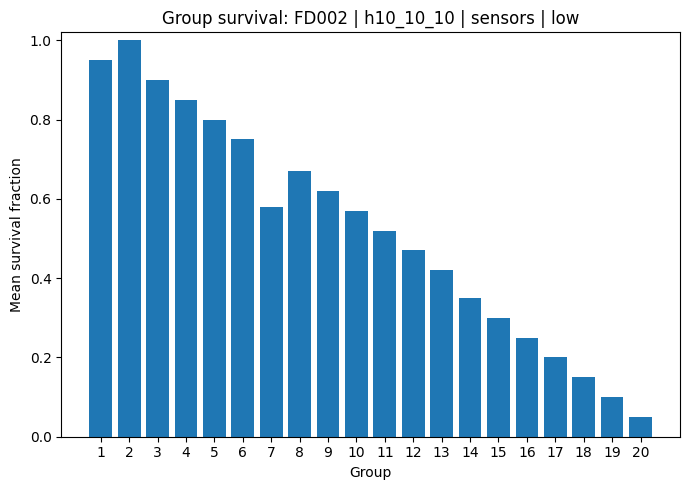

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD002_h10_10_10_sensors_low.png


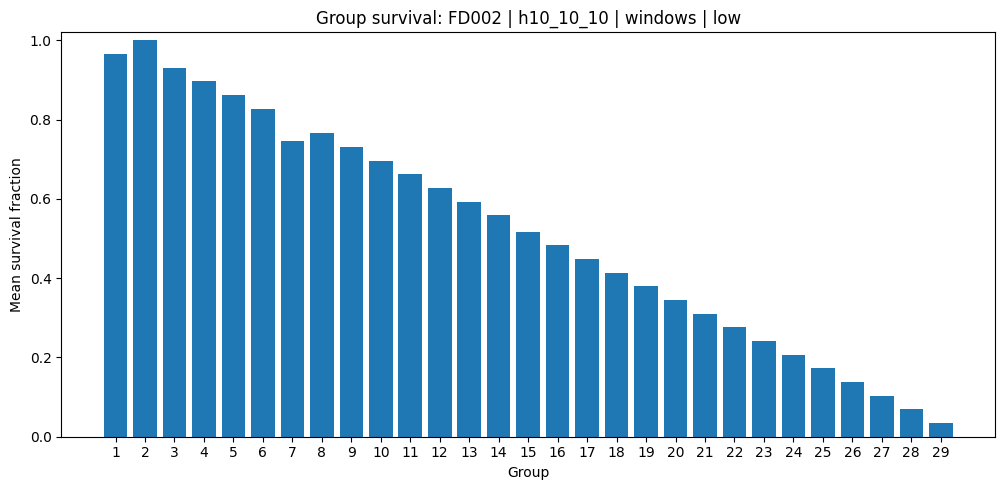

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD002_h10_10_10_windows_low.png


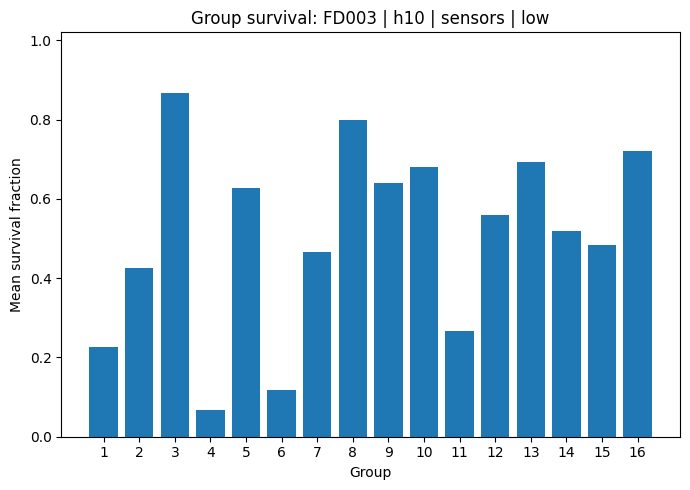

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD003_h10_sensors_low.png


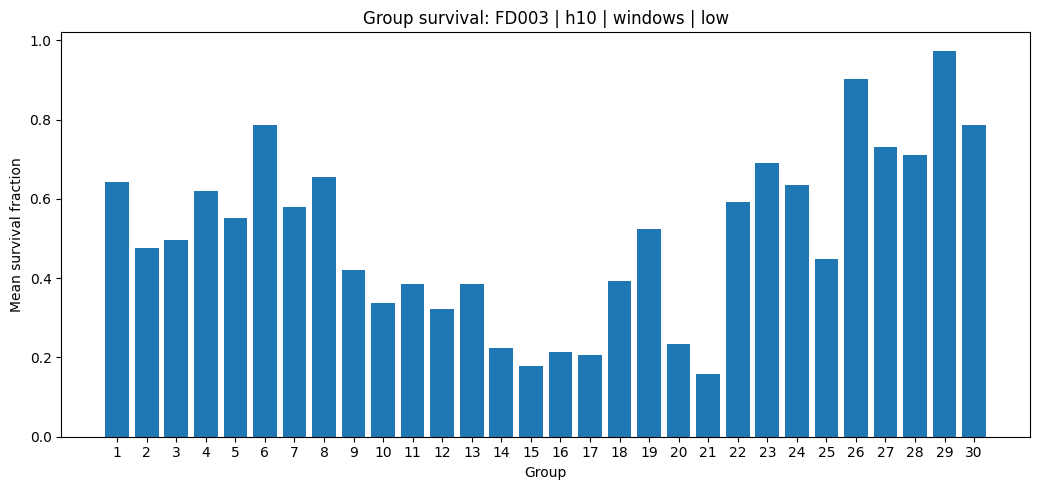

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD003_h10_windows_low.png


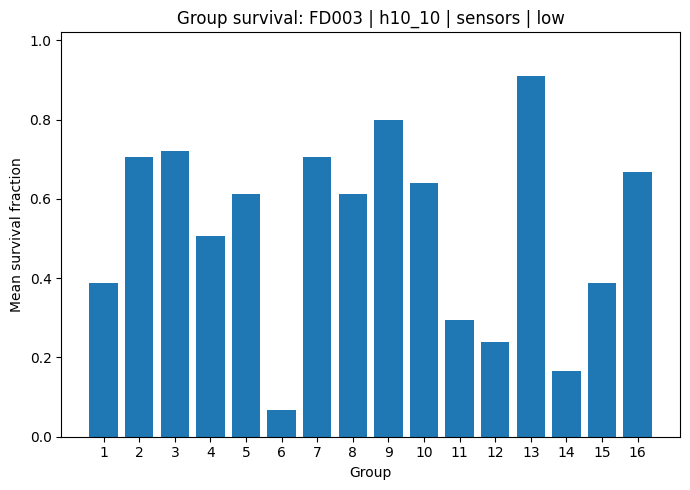

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD003_h10_10_sensors_low.png


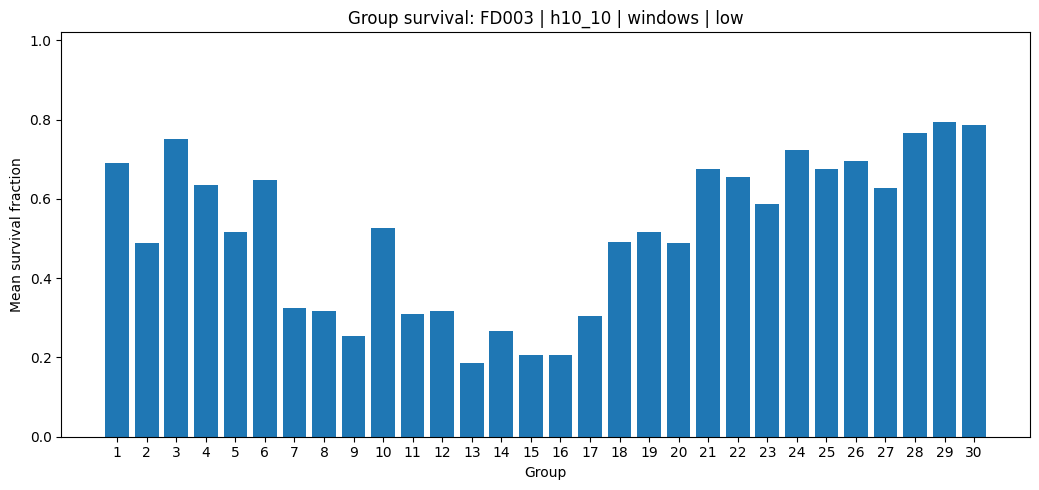

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD003_h10_10_windows_low.png


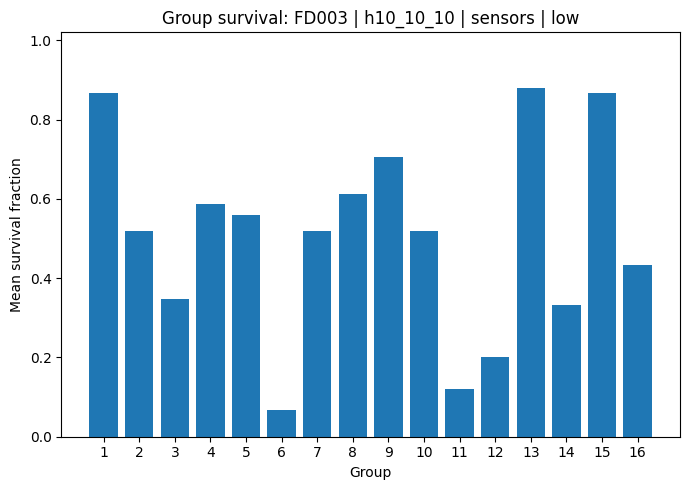

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD003_h10_10_10_sensors_low.png


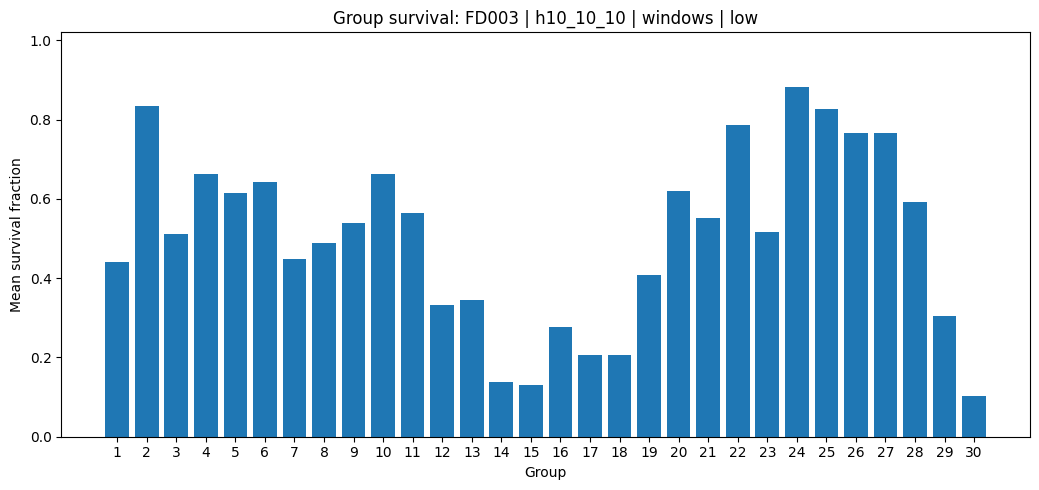

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD003_h10_10_10_windows_low.png


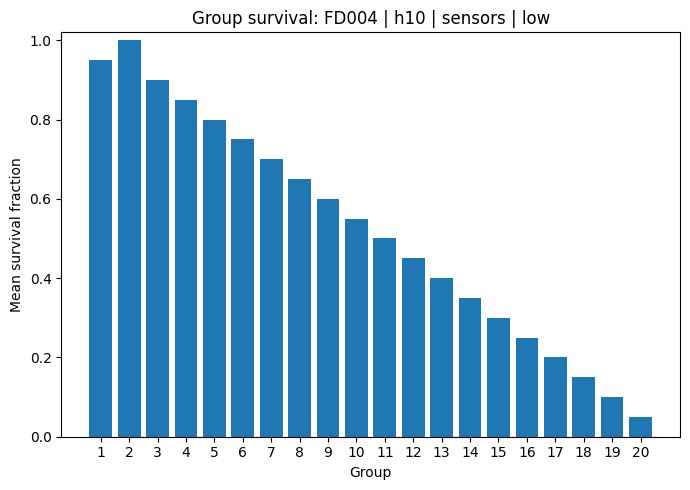

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD004_h10_sensors_low.png


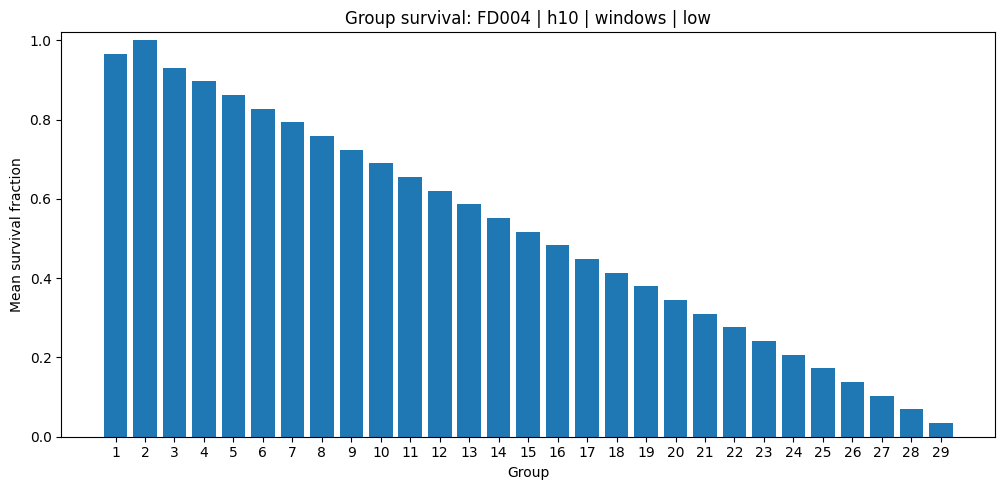

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD004_h10_windows_low.png


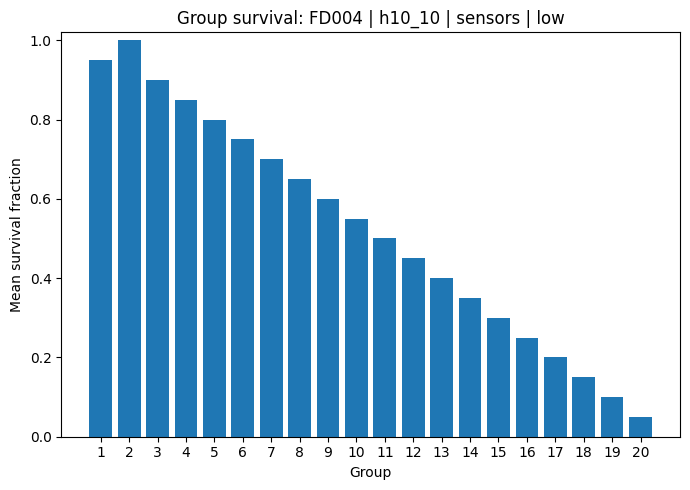

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD004_h10_10_sensors_low.png


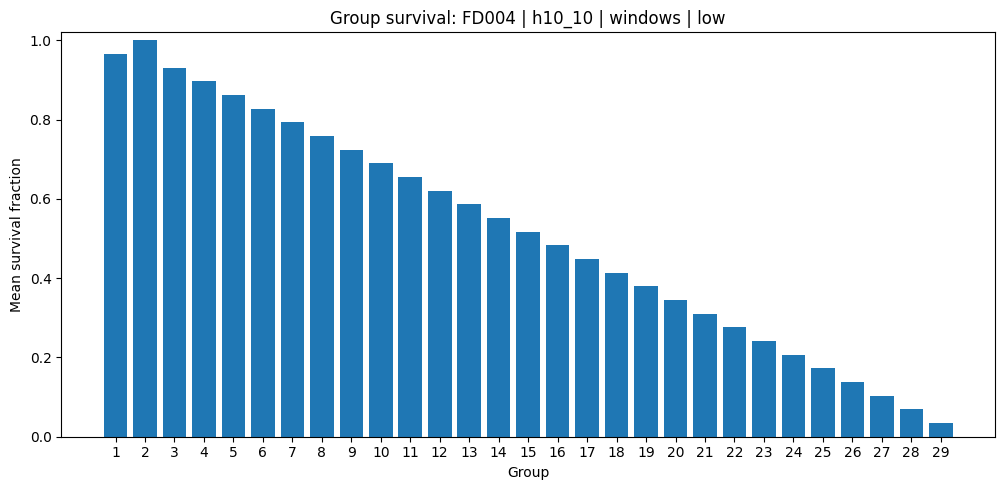

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD004_h10_10_windows_low.png


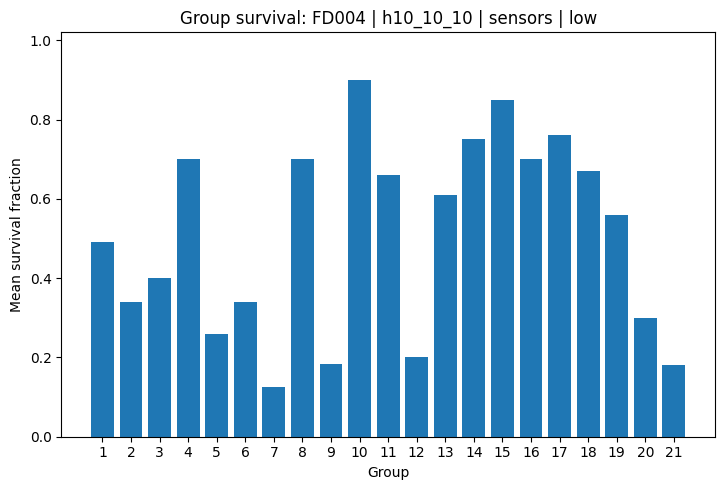

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD004_h10_10_10_sensors_low.png


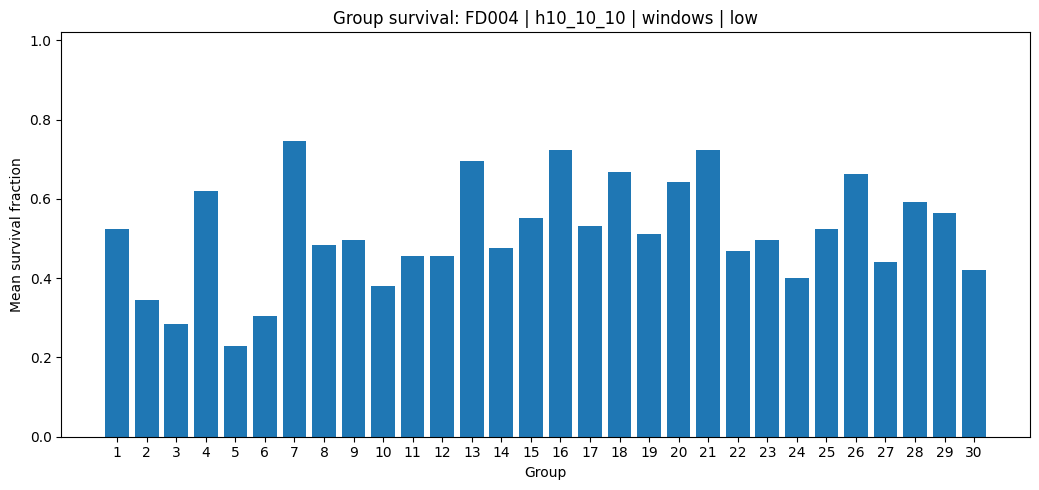

Guardada: results/time_trust_stability_lowrul/notebook_exports/survival_frequency_plots/survival_FD004_h10_10_10_windows_low.png


In [27]:
surv_dir = OUT_DIR / "survival_frequency_plots"
surv_dir.mkdir(parents=True, exist_ok=True)

def group_sort_key(x):
    try:
        return int(x)
    except Exception:
        return str(x)

for (dataset, hidden_tag, mode, bin_name), g in survival_freq.groupby(["dataset", "hidden_tag", "mode", "bin"], dropna=False):
    g = g.copy()
    g["group_sort"] = g["group"].astype(str).map(group_sort_key)
    g = g.sort_values("group_sort")
    plt.figure(figsize=(max(7, len(g) * 0.35), 5))
    plt.bar(g["group"].astype(str), g["mean_survival_fraction"])
    plt.xlabel("Group")
    plt.ylabel("Mean survival fraction")
    plt.title(f"Group survival: {dataset} | {hidden_tag} | {mode} | {bin_name}")
    plt.ylim(0, 1.02)
    plt.tight_layout()
    fig_path = surv_dir / f"survival_{dataset}_{hidden_tag}_{mode}_{bin_name}.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Guardada:", fig_path)

## 12. Verificar cobertura del sweep

In [28]:
expected_datasets = ["FD001", "FD002", "FD003", "FD004"]
expected_hidden = ["h10", "h10_10", "h10_10_10"]
expected_modes = ["sensors", "windows"]

observed = runtime[["dataset", "hidden_tag", "mode", "n_runs", "n_ok"]].drop_duplicates()
expected = pd.MultiIndex.from_product(
    [expected_datasets, expected_hidden, expected_modes],
    names=["dataset", "hidden_tag", "mode"]
).to_frame(index=False)

coverage = expected.merge(observed, on=["dataset", "hidden_tag", "mode"], how="left")
coverage["present"] = coverage["n_runs"].notna()
coverage["complete_ok"] = coverage["present"] & (coverage["n_runs"] == coverage["n_ok"])

coverage.to_csv(OUT_DIR / "coverage_check.csv", index=False)
coverage

,dataset,hidden_tag,mode,n_runs,n_ok,present,complete_ok
0,FD001,h10,sensors,5,5,True,True
1,FD001,h10,windows,5,5,True,True
2,FD001,h10_10,sensors,5,5,True,True
3,FD001,h10_10,windows,5,5,True,True
4,FD001,h10_10_10,sensors,5,5,True,True
5,FD001,h10_10_10,windows,5,5,True,True
6,FD002,h10,sensors,5,5,True,True
7,FD002,h10,windows,5,5,True,True
8,FD002,h10_10,sensors,5,5,True,True
9,FD002,h10_10,windows,5,5,True,True


## 13. Exportar LaTeX

In [30]:
latex_dir = OUT_DIR / "latex"
latex_dir.mkdir(parents=True, exist_ok=True)

runtime_latex = runtime_table[[
    "dataset", "MLP", "Mode", "Runs", "OK runs",
    "Runtime mean ± std (s)", "CV", "P95 runtime (s)"
]].copy()

combined_latex = combined_table[[
    "dataset", "MLP", "Mode", "Runs", "OK runs",
    "Mean runtime (s)", "Std runtime (s)", "Runtime CV",
    "Jaccard @ >=50% groups", "Jaccard @ final"
]].copy()

for df_ in [runtime_latex, combined_latex]:
    for c in df_.columns:
        if pd.api.types.is_numeric_dtype(df_[c]):
            df_[c] = df_[c].round(3)

with open(latex_dir / "runtime_table.tex", "w", encoding="utf-8") as f:
    f.write(runtime_latex.to_latex(index=False, escape=False, caption="Runtime stability of Time-TRUST on low-RUL draws."))

with open(latex_dir / "runtime_plus_selection_stability_table.tex", "w", encoding="utf-8") as f:
    f.write(combined_latex.to_latex(index=False, escape=False, caption="Runtime and group-selection stability on low-RUL draws."))

print("Guardado:")
print("-", latex_dir / "runtime_table.tex")
print("-", latex_dir / "runtime_plus_selection_stability_table.tex")

Guardado:
- results/time_trust_stability_lowrul/notebook_exports/latex/runtime_table.tex
- results/time_trust_stability_lowrul/notebook_exports/latex/runtime_plus_selection_stability_table.tex


## 14. Frases interpretativas rápidas

In [31]:
def describe_row(r):
    runtime_txt = f'{r["Mean runtime (s)"]:.1f} ± {r["Std runtime (s)"]:.1f} s'
    cv = f'{r["Runtime CV"]:.3f}' if pd.notnull(r["Runtime CV"]) else "NA"
    j50 = f'{r["Jaccard @ >=50% groups"]:.3f}' if pd.notnull(r["Jaccard @ >=50% groups"]) else "NA"
    jf = f'{r["Jaccard @ final"]:.3f}' if pd.notnull(r["Jaccard @ final"]) else "NA"
    return (
        f'{r["dataset"]} {r["MLP"]} {r["Mode"]}: runtime {runtime_txt} '
        f'(CV={cv}); Jaccard >=50% groups={j50}; final Jaccard={jf}.'
    )

for _, r in combined_table.iterrows():
    print("- " + describe_row(r))

- FD001 h10 sensors: runtime 260.6 ± 2.1 s (CV=0.008); Jaccard >=50% groups=0.772; final Jaccard=0.100.
- FD001 h10 windows: runtime 522.9 ± 5.8 s (CV=0.011); Jaccard >=50% groups=0.749; final Jaccard=0.400.
- FD001 h10_10 sensors: runtime 331.7 ± 9.1 s (CV=0.027); Jaccard >=50% groups=0.577; final Jaccard=0.100.
- FD001 h10_10 windows: runtime 628.7 ± 23.1 s (CV=0.037); Jaccard >=50% groups=0.614; final Jaccard=0.600.
- FD001 h10_10_10 sensors: runtime 504.2 ± 48.9 s (CV=0.097); Jaccard >=50% groups=0.755; final Jaccard=0.100.
- FD001 h10_10_10 windows: runtime 948.1 ± 39.2 s (CV=0.041); Jaccard >=50% groups=0.768; final Jaccard=0.600.
- FD002 h10 sensors: runtime 451.1 ± 4.1 s (CV=0.009); Jaccard >=50% groups=1.000; final Jaccard=1.000.
- FD002 h10 windows: runtime 651.6 ± 4.9 s (CV=0.008); Jaccard >=50% groups=1.000; final Jaccard=1.000.
- FD002 h10_10 sensors: runtime 492.5 ± 4.1 s (CV=0.008); Jaccard >=50% groups=1.000; final Jaccard=1.000.
- FD002 h10_10 windows: runtime 702.9 ± 

## 15. Qué usar en el paper

Recomendación:

- Tabla principal: `runtime_plus_selection_stability_table.csv`.
- Runtime: reportar `mean ± std` y `CV`.
- Estabilidad: reportar Jaccard a sparsity moderada, no solo el grupo final.
- Figura principal: curvas de Jaccard por \(n_0\), porque muestran cómo la estabilidad disminuye con mayor sparsity.
- Supervivencia: usarla como análisis complementario para identificar grupos que permanecen relevantes durante la eliminación.